In [1]:
# ==============================================================================
# ECOLOGICAL INVASION RISK GNN — PRODUCTION WORKFLOW
#
# Predicts which alien species are most likely to establish in a target country
# by combining four complementary signals:
#
#   1. Relational ecology  — heterogeneous GNN over species interactions and
#                            taxonomy (GraphSAGE, 2 layers)
#   2. Climate niche       — Mahalanobis distance between a species' realized
#                            climate niche (mean ± std across known range) and
#                            the target country's climate profile
#   3. Trade pathways      — ecological risk channels (flora, fauna, agriculture
#                            etc.) derived from BACI UN trade data, routed
#                            dynamically through confirmed species presence
#   4. Biotic opportunity  — fraction of a species' GloBI interaction partners
#                            already present in the target country (pos/neg split)
#
# LABELS ARE POSITIVE-UNLABELED (PU): positives are SInAS established aliens;
# every other pair is UNLABELED (real absence, undetected invasion, or already
# native/present). Negatives are drawn only from pairs not recorded anywhere,
# and niche / trade features are computed as if the scored pair were not
# recorded (pair-level leave-one-out). See the changelog cell below.
#
# Architecture:
#   CountryAutoencoder        — encodes 7-dim climate vector → 32-dim latent
#   RelationalEcologicalGNN   — 2-layer HeteroSAGE over species + taxonomy
#   TradePathwayEncoder       — fuses import/export trade profiles per pair
#   NicheMatchingPredictor    — 5-stream classifier with detached climate gate
#
# Data requirements:
#   sinas_matched_species.csv         — SINAS alien/native species records
#   matched_globi_network.csv         — species-level GloBI interactions
#   matched_globi_network_higher_order.csv — genus/family/order-level interactions
#   aligned_country_climate.csv       — 7 climate variables per country
#   trade_channels.pt                 — pre-processed BACI trade tensor
#   gbif_presence.pt                  — GBIF presence matrix + bio-opp matrix
#
# !pip install torch_geometric pygbif country_converter -q
# ==============================================================================

import os, time, logging
from collections import defaultdict

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from pathlib import Path
from torch_geometric.data import HeteroData
from torch_geometric.nn import HeteroConv, SAGEConv, LayerNorm
from tqdm.auto import tqdm
from pygbif import species as gbif_species
from pygbif import occurrences
from sklearn.metrics import roc_curve, precision_recall_curve, auc
import matplotlib.pyplot as plt
import country_converter as coco

logging.getLogger('country_converter').setLevel(logging.ERROR)

# Changelog: positive-unlabeled (PU) fix and presence-leakage fix

**Problem 1: "negatives" included native and already-present pairs.** There are no true negatives here. A sampled negative is any pair not listed as an established alien, so it can be a real absence, an undetected invasion, or a species that is already native or present. The old samplers excluded only the `established_in` pairs, so `native_ei` and `presence_mat` pairs were drawn as negatives.

**Problem 2: presence leaked into the features.** Every positive is in the range data, so its target country sat inside the species' niche and trade-routing mask, while negatives never did. The model could learn "target in niche means positive", which does not exist at scan time.

| Area | Change |
|---|---|
| Negatives (§7) | Drawn only from pairs outside `exclude_mask` (SInAS native/alien/other rows + GBIF presence). Vectorised, no Python tuple lookups. `positive_set` is gone. |
| Niche (§6) | `compute_realized_climate_niche` replaced by `RangeStats.niche(sp, co)`: per-pair niche with that pair's country left out. |
| Trade routing (§6/§7) | `trade_export_vector` leaves the destination out of the species' range mask. |
| Per-split masking (§9) | Held-out positives are zeroed in a copy of the range matrix, so no validation pair feeds any feature. |
| Predictor (§6) | `forward` takes per-pair `realized_mean` / `realized_std` instead of per-species tensors. |
| Evaluation (§9/§10) | Added ranking metrics, species-held-out CV, and a leaky-vs-fixed climate-AUC diagnostic. Labels now say "unlabeled", not "true absence". |
| Labels (§1) | `non-native` is no longer matched as native. Native flag (species feature 3) now comes from SInAS native rows only. |
| Scan (§13/§14) | Candidates = has signal and not recorded anywhere, in both the live and static scanners. Static checkpoint stores `range_mat`, `exclude_mask` and the niche sums. |

**Expect lower AUC than before.** The previous run (production ROC-AUC 0.9575, PR-AUC 0.6498) was inflated by both problems. Keep that output as the "before" side of a leakage ablation.

**Not fixable in this notebook:** the GBIF country-to-sub-national over-marking (e.g. one US record marking Alaska, Hawaii and Puerto Rico as present) happens in the fetch notebook. It over-excludes negatives and inflates niches.


In [2]:
# ==============================================================================
# 1. DATA LOADING
# ==============================================================================
print("📖 Reading repository datasets...")

#repo_root = Path('/content')   # FOR IN GOOGLE COLLAB
repo_root         = Path.cwd().parent # FOR LOCAL REPO
repo_root = repo_root / "data" #FOr LOCAL REPO

sinas_path         = repo_root / 'sinas_matched_species.csv'
network_path       = repo_root / 'matched_globi_network.csv'
higher_order_path  = repo_root / 'matched_globi_network_higher_order.csv'
climate_path       = repo_root / 'aligned_country_climate.csv'
trade_path         = repo_root / 'trade_channels.pt'
baci_path          = repo_root / 'BACI_HS17_Y2019_V202401.csv'
gbif_presence_path = repo_root / 'gbif_presence_split.pt'
country_col        = 'location'

df_sinas   = pd.read_csv(sinas_path,        engine='python', on_bad_lines='warn')
df_net     = pd.read_csv(network_path,       engine='python', on_bad_lines='warn')
df_higher  = pd.read_csv(higher_order_path,  engine='python', on_bad_lines='warn')
df_climate = pd.read_csv(climate_path,       engine='python', on_bad_lines='warn')

print(f"   SInAS rows          : {len(df_sinas):,}")
print(f"   Species-level GloBI : {len(df_net):,}")
print(f"   Higher-order GloBI  : {len(df_higher):,}")
print(f"   Climate rows        : {len(df_climate):,}")

df_sinas = df_sinas.dropna(subset=['gbif_id']).copy()
df_sinas['gbif_id'] = df_sinas['gbif_id'].astype(int)

# Parse establishment status from SInAS establishmentMeans.
#   is_alien  -> introduced / invasive / naturalised / alien / NON-native
#                (training positives)
#   is_native -> native / indigenous AND not matched as alien. 'non-native'
#                contains the substring 'native', so the old bare
#                .contains('native') filed non-native records under NATIVE range
#                (niche, exclusion, native flag).
#   Rows matching neither (cryptogenic, unknown, ...) are neither positives nor
#   native range, but are still treated as "recorded" and never sampled as negatives.
_em = df_sinas['establishmentMeans'].fillna('').str.lower().str.strip()
df_sinas['is_alien']  = _em.str.contains(
    r'introduced|invasive|naturali[sz]ed|alien|non[\s_-]?native', regex=True)
df_sinas['is_native'] = (_em.str.contains(r'native|indigenous', regex=True)
                         & ~df_sinas['is_alien'])
print("   establishmentMeans values (check the matching above against these):")
print(df_sinas['establishmentMeans'].value_counts(dropna=False).head(15).to_string())
print(f"   is_native: {int(df_sinas['is_native'].sum()):,} | "
      f"is_alien: {int(df_sinas['is_alien'].sum()):,} | "
      f"neither: {int((~df_sinas['is_native'] & ~df_sinas['is_alien']).sum()):,}")


📖 Reading repository datasets...
   SInAS rows          : 378,728
   Species-level GloBI : 952,088
   Higher-order GloBI  : 444,765
   Climate rows        : 289
   establishmentMeans values (check the matching above against these):
establishmentMeans
native                   214474
introduced               152378
introduced; uncertain      7656
uncertain                  4215
vagrant                       5
   is_native: 214,474 | is_alien: 160,034 | neither: 4,220


In [3]:
# ==============================================================================
# 2. INTERACTION TYPE ONTOLOGY
#    Maps raw GloBI strings to four ecological categories.
#    'unknown' terms are tracked for transparency but excluded from edges.
# ==============================================================================
CONSUMPTION_TERMS = {
    'eats','preysOn','parasitizes','pathogenOf','parasitoidOf','consumes',
    'endoparasitoidOf','ectoparasitoidOf','endoparasiteOf','ectoparasiteOf',
    'scavenges','browses','grazesOn','hasHost','kills','saprophyteOf',
    'hyperparasiteOf','hyperparasitoidOf','bloodFeedsOn','nectarFeedsOn',
    'pollenFeedsOn','seedEaterOf','woodBorerOf','leafMinerOf','gallMakerOf',
    'defoliatorOf','rootFeederOf','vectorOf', 'parasiteOf', 'hemiparasiteOf', 'ectoParasitoid',
    'kleptoparasiteOf', 'rootparasiteOf', 'laysEggsOn', 'laysEggsIn'
}

MUTUALISM_TERMS = {
    'pollinates','visitsFlowersOf','symbiontOf','mutualistOf','associatedWith',
    'coOccursWith','hasSymbiont','commensalistOf','hasCommensalist','epiphyteOf',
    'hasEpiphyte','inquilineOf','hasInquiline','phoreticOf','hasPhoretic',
    'mycorrhizalWith','dispersesSeedsOf','disperses','vectorFor','sheltersWithin',
    'providesShelterTo','nestedIn','hostsNestedIn','flowersVisitedBy','visitedBy', 'hasVector',
    'hasDispersalVector', 'guestOf', 'coRoostsWith', 'hasHabitat', 'hasRoost', 'livesOn',
    'livesInsideOf', 'livesUnder', 'livesNear', 'inhabits'
}
COMPETITION_TERMS = {
    'competesWith','interferesWith','allelopathicTo','inhibits',
    'displaces','antagonistOf', 'allelopathOf'
}
VICTIM_TERMS = {
    'hostOf','hasParasite','hasPathogen','hasParasitoid','preyedOnBy','eatenBy', 'providesNutrientsFor',
    'parasitizedBy','infectedBy','killedBy','preyedUponBy','parasitoidBy','pathogenBy'
}

def categorize_interaction(itype: str) -> str:
    """Map a raw GloBI interaction type to resource/enemy/mutualism/competition/unknown."""
    if pd.isna(itype): return 'unknown'
    c = itype.strip(); l = c.lower()
    if c in CONSUMPTION_TERMS:  return 'resource'
    if c in MUTUALISM_TERMS:    return 'mutualism'
    if c in COMPETITION_TERMS:  return 'competition'
    if c in VICTIM_TERMS:       return 'enemy'
    if 'by' in l and any(w in l for w in ['eat','prey','parasit','kill','infect','attack']):
        return 'enemy'
    if any(w in l for w in ['eat','prey','consume','host','feed','graze','browse','destroy']):
        return 'resource'
    if any(w in l for w in ['symbio','mutual','pollin','cooccur','visit','associat','commens','shelter']):
        return 'mutualism'
    if any(w in l for w in ['compet','inhib','displac','antagon','resist','exclude']):
        return 'competition'
    return 'unknown'

all_interaction_types = pd.concat(
    [df_net['interaction_type'], df_higher['interaction_type']]
).dropna().unique()
interaction_mapping = {t: categorize_interaction(t) for t in all_interaction_types}

_cat_counts = pd.Series(list(interaction_mapping.values())).value_counts()
print("   Interaction category breakdown (unique raw terms):")
for cat, cnt in _cat_counts.items():
    print(f"     {cat}: {cnt}")
_all_mapped = (pd.concat([df_net['interaction_type'], df_higher['interaction_type']])
               .map(lambda t: interaction_mapping.get(t, 'unknown') if pd.notna(t) else 'unknown'))
_unk_frac = (_all_mapped == 'unknown').mean()
print(f"   {_unk_frac:.1%} of all interaction records are 'unknown' (excluded from edges)")

   Interaction category breakdown (unique raw terms):
     mutualism: 19
     resource: 18
     unknown: 3
     competition: 1
     enemy: 1
   24.3% of all interaction records are 'unknown' (excluded from edges)


In [4]:
# ==============================================================================
# 2b. VERIFY TYPE OF UNKNOWN INTERACTIONS
#    Maps number of terms and their name that are classified as unknown.
# ==============================================================================

# Combine all raw interaction types into a single Series
all_raw_interactions = pd.concat(
    [df_net['interaction_type'], df_higher['interaction_type']]
).dropna()

# Filter the Series to only include terms that mapped to 'unknown'
unknown_terms_series = all_raw_interactions[
    all_raw_interactions.map(lambda t: interaction_mapping.get(t, 'unknown')) == 'unknown'
]

# Get the value counts for the 23 unique unknown terms
unknown_counts = unknown_terms_series.value_counts()

print("### The 23 'Unknown' Terms and Their Frequencies ###")
print(unknown_counts)

### The 23 'Unknown' Terms and Their Frequencies ###
interaction_type
interactsWith            281849
adjacentTo                56934
ecologicallyRelatedTo      1045
Name: count, dtype: int64


In [5]:
# ==============================================================================
# 3. INDEX MAPPINGS
# ==============================================================================
print("⚙️ Engineering index maps...")

TAX_LEVELS = ['gbif_genus_id','gbif_family_id','gbif_order_id',
              'gbif_class_id','gbif_phylum_id','gbif_kingdom_id']
for col in TAX_LEVELS:
    if col in df_sinas.columns:
        df_sinas[col] = df_sinas[col].fillna(-1).astype(int)
    else:
        print(f"   ⚠️  Column '{col}' not found — filling with -1")
        df_sinas[col] = -1

sinas_sp   = set(df_sinas['gbif_id'].unique())
net_src_sp = set(df_net['source_gbif_id'].dropna().astype(int).unique())
net_tgt_sp = set(df_net['target_gbif_id'].dropna().astype(int).unique())
all_species_ids   = sorted(sinas_sp | net_src_sp | net_tgt_sp)
all_country_names = sorted(df_sinas[country_col].dropna().unique().tolist())

def build_tax_set(col):
    return set(df_sinas[df_sinas[col] != -1][col].unique())

unique_genera   = build_tax_set('gbif_genus_id')
unique_families = build_tax_set('gbif_family_id')
unique_orders   = build_tax_set('gbif_order_id')
unique_classes  = build_tax_set('gbif_class_id')
unique_phyla    = build_tax_set('gbif_phylum_id')
unique_kingdoms = build_tax_set('gbif_kingdom_id')

for rank, node_set in [('GENUS', unique_genera), ('FAMILY', unique_families),
                        ('ORDER', unique_orders), ('CLASS', unique_classes)]:
    for side in ['source', 'target']:
        ids = (df_higher[df_higher[f'{side}_rank'] == rank]
               [f'{side}_gbif_id'].dropna().astype(int).unique())
        node_set.update(ids)

unique_genera   = sorted(unique_genera)
unique_families = sorted(unique_families)
unique_orders   = sorted(unique_orders)
unique_classes  = sorted(unique_classes)
unique_phyla    = sorted(unique_phyla)
unique_kingdoms = sorted(unique_kingdoms)

sp_to_idx      = {sp_id: idx for idx, sp_id in enumerate(all_species_ids)}
idx_to_sp      = {v: k for k, v in sp_to_idx.items()}
co_to_idx      = {name: idx  for idx, name  in enumerate(all_country_names)}
idx_to_co      = {v: k for k, v in co_to_idx.items()}
genus_to_idx   = {g: i for i, g in enumerate(unique_genera)}
family_to_idx  = {f: i for i, f in enumerate(unique_families)}
order_to_idx   = {o: i for i, o in enumerate(unique_orders)}
class_to_idx   = {c: i for i, c in enumerate(unique_classes)}
phylum_to_idx  = {p: i for i, p in enumerate(unique_phyla)}
kingdom_to_idx = {k: i for i, k in enumerate(unique_kingdoms)}

num_species   = len(all_species_ids)
num_countries = len(all_country_names)
num_genera    = len(unique_genera)
num_families  = len(unique_families)
num_orders    = len(unique_orders)
num_classes   = len(unique_classes)
num_phyla     = len(unique_phyla)
num_kingdoms  = len(unique_kingdoms)

id_to_name = (df_sinas.drop_duplicates('gbif_id')
                       .set_index('gbif_id')['gbif_canonical_name'].to_dict())
for row in df_net.dropna(subset=['source_gbif_id']).drop_duplicates('source_gbif_id').itertuples():
    if int(row.source_gbif_id) not in id_to_name:
        id_to_name[int(row.source_gbif_id)] = row.source_taxon_name
for row in df_net.dropna(subset=['target_gbif_id']).drop_duplicates('target_gbif_id').itertuples():
    if int(row.target_gbif_id) not in id_to_name:
        id_to_name[int(row.target_gbif_id)] = row.target_taxon_name

print(f"   Species: {num_species:,} | Countries: {num_countries:,} | "
      f"Genera: {num_genera:,} | Families: {num_families:,} | "
      f"Orders: {num_orders:,} | Classes: {num_classes:,} | "
      f"Phyla: {num_phyla:,} | Kingdoms: {num_kingdoms:,}")

⚙️ Engineering index maps...
   Species: 167,357 | Countries: 289 | Genera: 22,182 | Families: 2,889 | Orders: 622 | Classes: 159 | Phyla: 51 | Kingdoms: 7


In [6]:
# ==============================================================================
# 4. CLIMATE FEATURES
#    7 climate variables per country, min-max normalised to [0, 1].
#    Normalisation uses global min/max across all countries — safe because
#    climate is a static, label-independent feature.
# ==============================================================================
CLIMATE_COLS = ['latitude','longitude','mean_temperature',
                'temperature_seasonality','frost_days',
                'precipitation','aridity_index']
n_co_features = len(CLIMATE_COLS)

climate_lookup    = df_climate.set_index('location')[CLIMATE_COLS].to_dict(orient='index')
co_feature_matrix = torch.zeros(num_countries, n_co_features)
missing_climate   = []

for country_name, co_idx in co_to_idx.items():
    if country_name in climate_lookup:
        vals = [climate_lookup[country_name][c] for c in CLIMATE_COLS]
        co_feature_matrix[co_idx] = torch.tensor(vals, dtype=torch.float)
    else:
        missing_climate.append(country_name)

for i in range(n_co_features):
    col = co_feature_matrix[:, i]
    col_min, col_max = col.min(), col.max()
    if col_max > col_min:
        co_feature_matrix[:, i] = (col - col_min) / (col_max - col_min)

co_climate_tensor = co_feature_matrix.clone()
if missing_climate:
    print(f"   ⚠️  {len(missing_climate)} countries missing climate data — zero vector used")
print(f"   Climate tensor: {co_climate_tensor.shape}")

   Climate tensor: torch.Size([289, 7])


In [7]:
# ==============================================================================
# 4b. TRADE CHANNELS
# ==============================================================================
print("📦 Loading trade channel tensor...")

ECOLOGICAL_TRADE_MAPPING = {
    'flora_and_timber': ('06', '44'),
    'aquatic_fauna':    ('03',),
    'terrestrial_pets': ('01',),
    'agri_hitchhikers': ('07', '08', '10', '12'),
    'microbial_risk':   ('3002', '3821'),
}
channel_keys = list(ECOLOGICAL_TRADE_MAPPING.keys())
num_channels = len(channel_keys)

SUB_NATIONAL_TO_ISO = {
    'Aegean':'GRC','Caspian Sea':'RUS','Alaska':'USA','Hawaii':'USA',
    'Virgin Islands (U.S.)':'USA','United States Minor Outlying Islands':'USA',
    'Puerto Rico':'USA','Guam':'USA','American Samoa':'USA',
    'Northern Mariana Islands':'USA','Canary Islands':'ESP','Balearic Islands':'ESP',
    'Azores':'PRT','Madeira':'PRT','Sicily':'ITA','Sardinia':'ITA',
    'Tasmania':'AUS','Lord Howe Islands':'AUS','Norfolk Island':'AUS',
    'Christmas Island':'AUS','Cocos Islands':'AUS','Galapagos':'ECU',
    'Corsica':'FRA','Réunion':'FRA','Mayotte':'FRA','Guadeloupe':'FRA',
    'Martinique':'FRA','French Guiana':'FRA','Saint Pierre and Miquelon':'FRA',
    'Saint-Barthélemy':'FRA','Saint-Martin':'FRA','Amsterdam Island':'FRA',
    'Crozet Islands':'FRA','Kerguelen Islands':'FRA','St. Paul Island':'FRA',
    'Scattered Islands':'FRA','Shetland Islands':'GBR','Guernsey':'GBR',
    'Jersey':'GBR','Isle of Man':'GBR','Akrotiri and Dhekelia':'GBR',
    'Gibraltar':'GBR','Bermuda':'GBR','Anguilla':'GBR','Cayman Islands':'GBR',
    'Montserrat':'GBR','Turks and Caicos Islands':'GBR',
    'Virgin Islands (British)':'GBR','Falkland Islands':'GBR',
    'Pitcairn Islands':'GBR','Saint Helena':'GBR','Ascension':'GBR',
    'Tristan da Cunha':'GBR','Chagos Archipelago':'GBR',
    'South Georgia and the South Sandwich Islands':'GBR','Vancouver Island':'CAN',
    'Crete':'GRC','Zanzibar Island':'TZA','Rapa Nui':'CHL','Socotra Island':'YEM',
    'Nicobar and Andaman Islands':'IND','Rodriguez Island':'MUS',
    'Hong Kong':'CHN','Macao':'CHN','Bonaire':'NLD','Saba':'NLD',
    'Sint Eustatius':'NLD','Curaçao':'NLD','Sint Maarten':'NLD',
    'Faroe Islands':'DNK','Greenland':'DNK','Svalbard and Jan Mayen':'NOR',
    'Bouvet Island':'NOR','Åland':'FIN','Tokelau':'NZL','Niue':'NZL',
    'Cook Islands':'NZL','Kermadec Islands':'NZL','Northern Cyprus':'CYP',
    'Western Sahara':'MAR','Fernando de Noronha':'BRA','Paracel Islands':'CHN',
    'Spratly Islands':'CHN','Palestine':'PSE','Kosovo':'XKX',
    'Antipodes Island':'NZL','Izu Islands':'JPN','Ogasawara Islands':'JPN',
}

cc = coco.CountryConverter()
name_to_iso3 = {}
for name in all_country_names:
    if name in SUB_NATIONAL_TO_ISO:
        name_to_iso3[name] = SUB_NATIONAL_TO_ISO[name]
    else:
        iso3 = cc.convert(names=name, to='ISO3')
        name_to_iso3[name] = 'WLD' if iso3 == 'not_found' else iso3

iso3_to_graph_indices = defaultdict(list)
for name, iso3 in name_to_iso3.items():
    iso3_to_graph_indices[iso3].append(co_to_idx[name])

N = num_countries

if trade_path.exists():
    trade_data            = torch.load(trade_path, map_location='cpu', weights_only=False)
    trade_channels_tensor = trade_data['trade_tensor']
    trade_channels_list   = trade_data['channels_order']
    print(f"   Loaded trade tensor: {trade_channels_tensor.shape}")
    if trade_channels_tensor.shape[0] != num_channels:
        raise ValueError(f"trade_tensor has {trade_channels_tensor.shape[0]} channels "
                         f"but mapping defines {num_channels}.")
else:
    if not baci_path.exists():
        raise FileNotFoundError(f"Neither {trade_path} nor {baci_path} found.")
    print(f"   Building from {baci_path.name}...")
    baci_ids        = pd.read_csv(baci_path, usecols=['i', 'j'])
    unique_un_codes = list(set(baci_ids['i'].unique()) | set(baci_ids['j'].unique()))
    converted       = cc.convert(names=unique_un_codes, src='UNcode', to='ISO3')
    if not isinstance(converted, list): converted = [converted]
    baci_num_to_iso3 = {num: iso3 for num, iso3 in zip(unique_un_codes, converted)
                        if iso3 != 'not_found'}
    channel_idx_map    = {k: i for i, k in enumerate(channel_keys)}
    raw_trade_matrices = np.zeros((num_channels, N, N), dtype=np.float64)
    baci_dtypes        = {'t': np.int16, 'k': np.int32, 'i': np.int16,
                          'j': np.int16, 'v': np.float32}
    with pd.read_csv(baci_path, dtype=baci_dtypes, chunksize=250_000) as reader:
        for chunk in tqdm(reader, desc="Processing BACI"):
            chunk['exp_iso'] = chunk['i'].map(baci_num_to_iso3)
            chunk['imp_iso'] = chunk['j'].map(baci_num_to_iso3)
            chunk = chunk.dropna(subset=['exp_iso','imp_iso'])
            chunk = chunk[chunk['exp_iso'].isin(iso3_to_graph_indices) &
                          chunk['imp_iso'].isin(iso3_to_graph_indices)]
            if chunk.empty: continue
            chunk['k_str'] = chunk['k'].astype(str).str.zfill(6)
            for ch_name, prefixes in ECOLOGICAL_TRADE_MAPPING.items():
                ch_idx = channel_idx_map[ch_name]
                sub_df = chunk[chunk['k_str'].str.startswith(prefixes)]
                if sub_df.empty: continue
                agg = sub_df.groupby(['exp_iso','imp_iso'])['v'].sum().reset_index()
                for row in agg.itertuples():
                    for e_idx in iso3_to_graph_indices[row.exp_iso]:
                        for i_idx in iso3_to_graph_indices[row.imp_iso]:
                            raw_trade_matrices[ch_idx, e_idx, i_idx] += float(row.v)
    trade_channels_tensor = torch.tensor(np.log1p(raw_trade_matrices), dtype=torch.float32)
    trade_channels_list   = channel_keys
    torch.save({'trade_tensor': trade_channels_tensor,
                'channels_order': trade_channels_list,
                'locations_order': all_country_names}, trade_path)

co_trade_import = trade_channels_tensor.sum(dim=1).T
co_trade_export = trade_channels_tensor.sum(dim=2).T
for c in range(num_channels):
    for mat in [co_trade_import, co_trade_export]:
        col_min, col_max = mat[:, c].min(), mat[:, c].max()
        if col_max > col_min:
            mat[:, c] = (mat[:, c] - col_min) / (col_max - col_min)
print(f"   Import profile: {co_trade_import.shape} | Export profile: {co_trade_export.shape}")

📦 Loading trade channel tensor...
   Loaded trade tensor: torch.Size([5, 289, 289])
   Import profile: torch.Size([289, 5]) | Export profile: torch.Size([289, 5])


In [8]:
# ==============================================================================
# 4c. GBIF PRESENCE + BIOTIC OPPORTUNITY MATRIX (pos/neg split)
#
#    presence_mat[sp, co] — species sp confirmed present in country co (GBIF)
#    pos_opp_mat[sp, co]  — fraction of sp's POSITIVE-valence GloBI partners
#                           (resource/mutualism: food, hosts, pollinators,
#                           symbionts) confirmed present in co
#    neg_opp_mat[sp, co]  — fraction of sp's NEGATIVE-valence GloBI partners
#                           (enemy/competition: predators, parasites,
#                           pathogens, competitors) confirmed present in co
#
#    Used for: (a) native_ei enrichment for realized niche, (b) biotic
#    opportunity score (now 2-dim: [pos, neg]), (c) dynamic trade routing.
#    NOT used for established_in edges — those come from SINAS exclusively.
#
#    CAUTION: GBIF presence includes occurrences of ALIEN populations, so it
#    means "already recorded", not "native". It is used to exclude pairs from
#    negatives / scan candidates and as range data, never as proof of nativity.
# ==============================================================================
print("🌿 Loading GBIF presence + biotic opportunity matrices (pos/neg split)...")
if not gbif_presence_path.exists():
    raise FileNotFoundError(f"{gbif_presence_path} not found. "
                            "Run fetch_gbif_presabs_country_pos_neg_split.ipynb first.")
_gbif        = torch.load(gbif_presence_path, map_location='cpu', weights_only=False)
presence_mat = _gbif['presence'].float()
pos_opp_mat  = _gbif['pos_opp_mat'].float()
neg_opp_mat  = _gbif['neg_opp_mat'].float()

assert _gbif['species_order']   == all_species_ids,   \
    "Species order mismatch — re-run fetch_gbif_presabs_country_pos_neg_split.ipynb"
assert _gbif['countries_order'] == all_country_names, \
    "Country order mismatch — re-run fetch_gbif_presabs_country_pos_neg_split.ipynb"

if not _gbif.get('complete', False):
    n_failed = len(_gbif.get('permanently_failed', []))
    print(f"   ⚠️  Presence data incomplete — {n_failed} species failed GBIF fetch.")
print(f"   Presence: {list(presence_mat.shape)} | "
      f"Pos-opp: {list(pos_opp_mat.shape)} | Neg-opp: {list(neg_opp_mat.shape)} | "
      f"Total presences: {int(presence_mat.sum()):,}")

def biotic_opportunity_score(sp_idx_batch, co_idx_batch):
    """
    Returns (B, 2) tensor: [fraction of positive-valence partners present,
    fraction of negative-valence partners present] for each (sp, co) pair.
    Kept split rather than averaged into one number — a species surrounded
    by predators should not score identically to one surrounded by
    prey/mutualists. See Section 8 of fetch_gbif_presabs_country_pos_neg_split.ipynb.
    """
    pos = pos_opp_mat[sp_idx_batch, co_idx_batch]
    neg = neg_opp_mat[sp_idx_batch, co_idx_batch]
    return torch.stack([pos, neg], dim=-1)

🌿 Loading GBIF presence + biotic opportunity matrices (pos/neg split)...
   Presence: [167357, 289] | Pos-opp: [167357, 289] | Neg-opp: [167357, 289] | Total presences: 3,311,662


In [9]:
# ==============================================================================
# 5. HETEROGENEOUS GRAPH CONSTRUCTION
# ==============================================================================
print("🕸️ Compiling HeteroData graph...")
data    = HeteroData()
emb_dim = 64
torch.manual_seed(42)

df_sinas['sp_idx'] = df_sinas['gbif_id'].map(sp_to_idx)
df_sinas['co_idx'] = df_sinas[country_col].map(co_to_idx)
native_df = df_sinas[df_sinas['is_native']].dropna(subset=['sp_idx','co_idx'])
alien_df  = df_sinas[df_sinas['is_alien']].dropna(subset=['sp_idx','co_idx'])

def tensor_edges(src_vals, tgt_vals):
    return torch.tensor([src_vals.astype(int), tgt_vals.astype(int)], dtype=torch.long)

data['species','native_to',       'country'].edge_index = tensor_edges(
    native_df['sp_idx'].values, native_df['co_idx'].values)
data['species','established_in',  'country'].edge_index = tensor_edges(
    alien_df['sp_idx'].values,  alien_df['co_idx'].values)
data['country','has_native',      'species'].edge_index = tensor_edges(
    native_df['co_idx'].values, native_df['sp_idx'].values)
data['country','has_established', 'species'].edge_index = tensor_edges(
    alien_df['co_idx'].values,  alien_df['sp_idx'].values)

df_tax = df_sinas.dropna(subset=['gbif_id']).drop_duplicates('gbif_id').copy()

def add_tax_edges(df, src_col, src_idx_col, src_map, src_node,
                  tgt_col, tgt_idx_col, tgt_map, tgt_node,
                  fwd_rel, rev_rel, dedup_col=None):
    """Add forward + reverse taxonomy edges. dedup_col avoids duplicate parent edges."""
    df = df.copy()
    df[src_idx_col] = df[src_col].map(src_map)
    df[tgt_idx_col] = df[tgt_col].map(tgt_map)
    sub = df.dropna(subset=[src_idx_col, tgt_idx_col])
    if dedup_col: sub = sub.drop_duplicates(dedup_col)
    if sub.empty: return
    data[src_node, fwd_rel, tgt_node].edge_index = tensor_edges(
        sub[src_idx_col].values, sub[tgt_idx_col].values)
    data[tgt_node, rev_rel, src_node].edge_index = tensor_edges(
        sub[tgt_idx_col].values, sub[src_idx_col].values)

add_tax_edges(df_tax,'gbif_id','sp_idx',sp_to_idx,'species',
              'gbif_genus_id','genus_idx',genus_to_idx,'genus',
              'belongs_to_genus','has_species')
add_tax_edges(df_tax,'gbif_genus_id','genus_idx',genus_to_idx,'genus',
              'gbif_family_id','family_idx',family_to_idx,'family',
              'belongs_to_family','has_genus', dedup_col='gbif_genus_id')
add_tax_edges(df_tax,'gbif_family_id','family_idx',family_to_idx,'family',
              'gbif_order_id','order_idx',order_to_idx,'order',
              'belongs_to_order','has_family', dedup_col='gbif_family_id')
add_tax_edges(df_tax,'gbif_order_id','order_idx',order_to_idx,'order',
              'gbif_class_id','class_idx',class_to_idx,'class',
              'belongs_to_class','has_order', dedup_col='gbif_order_id')
add_tax_edges(df_tax,'gbif_class_id','class_idx',class_to_idx,'class',
              'gbif_phylum_id','phylum_idx',phylum_to_idx,'phylum',
              'belongs_to_phylum','has_class', dedup_col='gbif_class_id')
add_tax_edges(df_tax,'gbif_phylum_id','phylum_idx',phylum_to_idx,'phylum',
              'gbif_kingdom_id','kingdom_idx',kingdom_to_idx,'kingdom',
              'belongs_to_kingdom','has_phylum', dedup_col='gbif_phylum_id')

# Species-level GloBI edges — 'unknown' category explicitly excluded
df_net_clean = df_net.dropna(
    subset=['interaction_type','source_gbif_id','target_gbif_id']).copy()
df_net_clean['src_idx']  = df_net_clean['source_gbif_id'].astype(int).map(sp_to_idx)
df_net_clean['tgt_idx']  = df_net_clean['target_gbif_id'].astype(int).map(sp_to_idx)
df_net_clean             = df_net_clean.dropna(subset=['src_idx','tgt_idx'])
df_net_clean['category'] = df_net_clean['interaction_type'].map(interaction_mapping)
df_net_clean             = df_net_clean[df_net_clean['category'] != 'unknown']

for cat in ['resource','mutualism','competition']:
    sub = df_net_clean[df_net_clean['category'] == cat]
    if not sub.empty:
        data['species',cat,'species'].edge_index = tensor_edges(
            sub['src_idx'].values, sub['tgt_idx'].values)

# Enemy edges: explicit enemy records + reverse of resource edges
enemy_df     = df_net_clean[df_net_clean['category'] == 'enemy']
res_df       = df_net_clean[df_net_clean['category'] == 'resource']
combined_src = np.concatenate([enemy_df['src_idx'].values, res_df['tgt_idx'].values])
combined_tgt = np.concatenate([enemy_df['tgt_idx'].values, res_df['src_idx'].values])
if len(combined_src) > 0:
    data['species','enemy','species'].edge_index = torch.tensor(
        [combined_src.astype(int), combined_tgt.astype(int)], dtype=torch.long)

# Higher-order GloBI edges
df_higher_clean = df_higher.dropna(
    subset=['interaction_type','source_gbif_id','target_gbif_id']).copy()
df_higher_clean['source_gbif_id'] = df_higher_clean['source_gbif_id'].astype(int)
df_higher_clean['target_gbif_id'] = df_higher_clean['target_gbif_id'].astype(int)
df_higher_clean['category']       = df_higher_clean['interaction_type'].map(interaction_mapping)
df_higher_clean                   = df_higher_clean[df_higher_clean['category'] != 'unknown']

def add_higher_order_edges(df, src_rank, tgt_rank, src_map, tgt_map,
                            src_node, tgt_node, rel_prefix):
    """Add interaction edges between higher-order taxonomic nodes."""
    sub = df[(df['source_rank'] == src_rank) & (df['target_rank'] == tgt_rank)].copy()
    sub['src_idx'] = sub['source_gbif_id'].map(src_map)
    sub['tgt_idx'] = sub['target_gbif_id'].map(tgt_map)
    sub = sub.dropna(subset=['src_idx','tgt_idx'])
    for cat in ['resource','mutualism','competition','enemy']:
        s = sub[sub['category'] == cat]
        if not s.empty:
            data[src_node, f'{rel_prefix}_{cat}', tgt_node].edge_index = tensor_edges(
                s['src_idx'].values, s['tgt_idx'].values)

add_higher_order_edges(df_higher_clean,'GENUS', 'GENUS', genus_to_idx,  genus_to_idx,  'genus', 'genus', 'genus')
add_higher_order_edges(df_higher_clean,'GENUS', 'SPECIES',genus_to_idx, sp_to_idx,     'genus', 'species','genus_sp')
add_higher_order_edges(df_higher_clean,'SPECIES','GENUS', sp_to_idx,    genus_to_idx,  'species','genus', 'sp_genus')
add_higher_order_edges(df_higher_clean,'FAMILY','FAMILY', family_to_idx,family_to_idx, 'family','family', 'family')
add_higher_order_edges(df_higher_clean,'ORDER', 'ORDER',  order_to_idx, order_to_idx,  'order', 'order',  'order')
add_higher_order_edges(df_higher_clean,'CLASS', 'CLASS',  class_to_idx, class_to_idx,  'class', 'class',  'class')

🕸️ Compiling HeteroData graph...


C:\Users\simon\AppData\Local\Temp\ipykernel_18836\2572947650.py:15: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:257.)
  return torch.tensor([src_vals.astype(int), tgt_vals.astype(int)], dtype=torch.long)


In [10]:
# ==============================================================================
# 5b. SPECIES NODE FEATURES (5 structural dimensions)
#    Feature 0: out-degree in resource edges
#    Feature 1: in-degree in enemy edges
#    Feature 2: out-degree in mutualism edges
#    Feature 3: native flag (SInAS native rows only; GBIF presence also covers
#               alien populations, so it must not define 'native')
#    Feature 4: total biotic degree (sum of 0-2)
#    No invasiveness count — would leak the training label.
# ==============================================================================
print("🧬 Engineering species node features...")

sinas_native_ei = data['species','native_to','country'].edge_index
gbif_pairs      = presence_mat.nonzero(as_tuple=False)
gbif_native_ei  = gbif_pairs.T.long()
native_ei       = torch.unique(
    torch.cat([sinas_native_ei, gbif_native_ei], dim=1), dim=1)
print(f"   Native edges — SINAS: {sinas_native_ei.shape[1]:,} | "
      f"GBIF: {gbif_native_ei.shape[1]:,} | Union: {native_ei.shape[1]:,}")

n_sp_features = 5
sp_features   = torch.zeros(num_species, n_sp_features)

for edge_cat, feat_col, row_idx in [
    ('resource',  0, 0),
    ('enemy',     1, 1),
    ('mutualism', 2, 0),
]:
    if ('species', edge_cat, 'species') in data.edge_index_dict:
        ei = data['species', edge_cat, 'species'].edge_index
        for idx in ei[row_idx]:
            sp_features[idx, feat_col] += 1

for idx in sinas_native_ei[0].unique():
    sp_features[idx, 3] = 1.0
sp_features[:, 4] = sp_features[:, 0] + sp_features[:, 1] + sp_features[:, 2]
for i in range(n_sp_features):
    m = sp_features[:, i].max()
    if m > 0: sp_features[:, i] /= m

data['species'].x = sp_features
data['country'].x = co_climate_tensor
print(f"   Species features: {data['species'].x.shape} | "
      f"Non-zero: {(sp_features.sum(1) > 0).sum().item():,}/{num_species:,}")

🧬 Engineering species node features...
   Native edges — SINAS: 214,474 | GBIF: 3,311,662 | Union: 3,311,662
   Species features: torch.Size([167357, 5]) | Non-zero: 125,373/167,357


In [11]:
# ==============================================================================
# 5c. BOTTOM-UP TAXONOMY INITIALISATION
#    Each taxonomy node initialised as the mean of its constituent species'
#    structural features, projected to emb_dim via a shared random matrix.
#    Gives the GNN a meaningful start rather than pure noise.
# ==============================================================================
print("🌳 Bottom-up taxonomic initialisation...")

df_tax['sp_idx']      = df_tax['gbif_id'].map(sp_to_idx)
df_tax['genus_idx']   = df_tax['gbif_genus_id'].map(genus_to_idx)
df_tax['family_idx']  = df_tax['gbif_family_id'].map(family_to_idx)
df_tax['order_idx']   = df_tax['gbif_order_id'].map(order_to_idx)
df_tax['class_idx']   = df_tax['gbif_class_id'].map(class_to_idx)
df_tax['phylum_idx']  = df_tax['gbif_phylum_id'].map(phylum_to_idx)
df_tax['kingdom_idx'] = df_tax['gbif_kingdom_id'].map(kingdom_to_idx)

tax_setup = {
    'genus':   ('sp_idx',     'genus_idx',   num_genera),
    'family':  ('genus_idx',  'family_idx',  num_families),
    'order':   ('family_idx', 'order_idx',   num_orders),
    'class':   ('order_idx',  'class_idx',   num_classes),
    'phylum':  ('class_idx',  'phylum_idx',  num_phyla),
    'kingdom': ('phylum_idx', 'kingdom_idx', num_kingdoms),
}
features_dict = {'species': sp_features}
prev_level    = 'species'

for lvl in ['genus','family','order','class','phylum','kingdom']:
    src_col, tgt_col, num_nodes = tax_setup[lvl]
    sub = df_tax.dropna(subset=[src_col, tgt_col]).drop_duplicates(src_col)
    lvl_feat  = torch.zeros(num_nodes, n_sp_features)
    lvl_count = torch.zeros(num_nodes, 1)
    if not sub.empty:
        tgt_t = torch.tensor(sub[tgt_col].values, dtype=torch.long)
        src_t = torch.tensor(sub[src_col].values, dtype=torch.long)
        lvl_feat.index_add_(0, tgt_t, features_dict[prev_level][src_t])
        lvl_count.index_add_(0, tgt_t, torch.ones(len(sub), 1))
        lvl_feat = lvl_feat / lvl_count.clamp(min=1)
    features_dict[lvl] = lvl_feat
    prev_level = lvl

proj_mat = torch.randn(n_sp_features, emb_dim) * (1.0 / np.sqrt(n_sp_features))
for lvl in ['genus','family','order','class','phylum','kingdom']:
    data[lvl].x = features_dict[lvl] @ proj_mat

print(f"   Taxonomy initialisation complete across {len(tax_setup)} levels")

🌳 Bottom-up taxonomic initialisation...
   Taxonomy initialisation complete across 6 levels


In [12]:
# ==============================================================================
# 6. MODEL ARCHITECTURE
# ==============================================================================

class CountryAutoencoder(nn.Module):
    """
    Encodes 7-dim climate vectors into a 32-dim latent space.
    Pre-trained with reconstruction loss so the climate representation is
    stable before the predictor starts training against it.
    """
    def __init__(self, n_features: int, latent_dim: int, hidden_dim: int = 64):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(n_features, hidden_dim), nn.GELU(),
            nn.LayerNorm(hidden_dim), nn.Dropout(0.1),
            nn.Linear(hidden_dim, latent_dim), nn.GELU(),
            nn.LayerNorm(latent_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim), nn.GELU(),
            nn.Linear(hidden_dim, n_features),
        )

    def forward(self, x):
        z = self.encoder(x)
        return z, self.decoder(z)

    def encode(self, x):
        return self.encoder(x)


class TradePathwayEncoder(nn.Module):
    """
    Fuses per-country import and export trade profiles into a latent vector.
    Channel attention learns which trade categories matter most per pair.
    """
    def __init__(self, num_channels: int, latent_dim: int, hidden_dim: int = 32):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(num_channels * 3, hidden_dim), nn.GELU(),
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, latent_dim), nn.GELU(),
            nn.LayerNorm(latent_dim),
        )
        self.channel_attn = nn.Sequential(
            nn.Linear(num_channels * 2, num_channels), nn.Sigmoid(),
        )

    def forward(self, import_vec, export_vec):
        interaction = import_vec * export_vec
        attn        = self.channel_attn(torch.cat([import_vec, export_vec], dim=-1))
        weighted    = interaction * attn
        return self.encoder(torch.cat([import_vec, export_vec, weighted], dim=-1))


def make_species_conv_schema(dim, edge_index_dict):
    """SAGEConv layers for species/taxonomy edges only (country nodes excluded)."""
    schema = {}
    for edge_type in edge_index_dict.keys():
        src, _, dst = edge_type
        if src == 'country' or dst == 'country': continue
        schema[edge_type] = (SAGEConv(dim, dim) if src == dst
                             else SAGEConv((dim, dim), dim))
    return schema


class RelationalEcologicalGNN(nn.Module):
    """
    2-layer heterogeneous GraphSAGE encoder over species + taxonomy.
    Layer 1 aggregates direct neighbours; layer 2 captures 2-hop structure.
    Countries excluded — encoded separately by CountryAutoencoder.
    """
    def __init__(self, dim, edge_index_dict, n_sp_features=5,
                 dropout=0.4, feature_dropout=0.35):
        super().__init__()
        self.sp_projector    = nn.Linear(n_sp_features, dim)
        self.feature_dropout = nn.Dropout(p=feature_dropout)
        sp_schema  = make_species_conv_schema(dim, edge_index_dict)
        self.conv1 = HeteroConv(sp_schema, aggr='mean')
        self.conv2 = HeteroConv(sp_schema, aggr='mean')
        sp_node_types = ['species','genus','family','order','class','phylum','kingdom']
        self.norm1 = nn.ModuleDict({n: LayerNorm(dim) for n in sp_node_types})
        self.norm2 = nn.ModuleDict({n: LayerNorm(dim) for n in sp_node_types})
        self.dropout = nn.Dropout(p=dropout)

    def forward(self, x_dict, edge_index_dict):
        x = {k: v for k, v in x_dict.items() if k != 'country'}
        x['species'] = self.sp_projector(x['species'])
        if self.training:
            x = {k: self.feature_dropout(v) for k, v in x.items()}
        sp_edge_dict = {et: ei for et, ei in edge_index_dict.items()
                        if et[0] != 'country' and et[2] != 'country'}
        x = self.conv1(x, sp_edge_dict)
        x = {k: self.norm1[k](self.dropout(F.gelu(v)))
             for k, v in x.items() if k in self.norm1}
        x = self.conv2(x, sp_edge_dict)
        x = {k: self.norm2[k](F.gelu(v))
             for k, v in x.items() if k in self.norm2}
        return x


class RangeStats:
    """
    Per-species range statistics with PAIR-LEVEL LEAVE-ONE-OUT.

    range_mat : (S, N) 0/1. Countries that count as known range for each
                species IN THIS SPLIT (held-out positives already zeroed by the
                caller). Used for the realized climate niche and trade routing.

    niche(sp, co) returns the species' climate (mean, std) over its range
    countries EXCLUDING `co` itself. Why: every positive is recorded, so its
    target country is inside its range, whereas a negative or a scan candidate
    never is. Without the correction the model can learn "target inside niche
    -> positive", a shortcut that does not exist at scan time. For pairs that
    are not in range_mat (negatives, scan candidates, masked validation
    positives) the correction does nothing.

    Species with no remaining range default to the global mean/std; species
    with exactly one remaining range country default to the global std
    (variance undefined).
    """
    def __init__(self, range_mat, co_climate):
        self.P          = range_mat
        self.co_climate = co_climate
        Pf = range_mat.float()
        self.sp_n   = Pf.sum(1, keepdim=True)          # (S, 1)
        self.sp_sum = Pf @ co_climate                  # (S, F)
        self.sp_sq  = Pf @ co_climate.pow(2)           # (S, F)
        self.g_mean = co_climate.mean(0, keepdim=True)
        self.g_std  = co_climate.std(0, keepdim=True).clamp(min=1e-4)

    def niche(self, sp_idx, co_idx, loo=True):
        x = self.co_climate[co_idx]                    # (B, F)
        n, s, q = self.sp_n[sp_idx], self.sp_sum[sp_idx], self.sp_sq[sp_idx]
        if loo:
            own = self.P[sp_idx, co_idx].float().unsqueeze(1)   # 1 if pair itself is range
            n, s, q = n - own, s - own * x, q - own * x.pow(2)
        mean = torch.where(n > 0, s / n.clamp(min=1), self.g_mean)
        ex2  = torch.where(n > 0, q / n.clamp(min=1),
                           self.g_mean.pow(2) + self.g_std.pow(2))
        var  = (ex2 - mean.pow(2)).clamp(min=1e-5)
        std  = torch.where(n > 1, var.sqrt(), self.g_std)
        return mean, std

    def state(self):
        """CPU tensors for the static checkpoint (range matrix stored as bool)."""
        return {'range_mat': self.P.bool().cpu(),
                'sp_n': self.sp_n.cpu(), 'sp_sum': self.sp_sum.cpu(),
                'sp_sq': self.sp_sq.cpu(),
                'g_mean': self.g_mean.cpu(), 'g_std': self.g_std.cpu()}

    @classmethod
    def from_state(cls, st, device='cpu'):
        """Rebuild from a checkpoint dict (needs 'co_climate_tensor' + state() keys)."""
        o = cls.__new__(cls)
        o.P          = st['range_mat'].to(device)
        o.co_climate = st['co_climate_tensor'].to(device)
        for k in ('sp_n', 'sp_sum', 'sp_sq', 'g_mean', 'g_std'):
            setattr(o, k, st[k].to(device))
        return o


def trade_export_vector(trade_channels, range_mat, sp_idx, co_idx, leave_pair_out=True):
    """
    Export profile into the destination, averaged over the species' range
    countries, WITHOUT the destination itself (pair-level leave-one-out, same
    reason as RangeStats.niche). Pure function of its arguments so the live
    notebook, the static scanner and the explainer all share it.
    Returns (B, C).
    """
    trade_to_dest = trade_channels[:, :, co_idx].permute(2, 0, 1)    # (B, C, N)
    mask = range_mat[sp_idx].float()                                 # (B, N), a copy
    if leave_pair_out:
        mask[torch.arange(len(co_idx), device=mask.device), co_idx] = 0.0
    mask = mask.unsqueeze(1)                                         # (B, 1, N)
    return (trade_to_dest * mask).sum(dim=2) / mask.sum(dim=2).clamp(min=1)


class NicheMatchingPredictor(nn.Module):
    """
    5-stream classifier combining ecology, climate, trade and biotic signals.

    Stream A — Topology (bottlenecked to sp_dim//4, gated by climate):
      Species GNN embedding × country climate latent. Deliberately narrow so
      graph connectivity cannot dominate. Multiplied by the climate gate —
      suppressed when species is climatically unsuited to the target country.

    Stream B — Mahalanobis climate niche (primary, wider at sp_dim//2):
      [realized_mean | target | |z_diff|] where z_diff = (mean-target)/std.
      Climate specialists punished more for the same raw deviation.

    Stream C — Per-feature suitability (n_co_features outputs, sigmoid):
      Learns which individual climate axes are most diagnostic per pair.

    Stream D — Trade pathway (sp_dim//4):
      TradePathwayEncoder over dynamically-routed import/export profiles.

    Stream E — Biotic opportunity (8-dim projection of a 2-dim [pos, neg] vector):
      [fraction of positive-valence GloBI partners present, fraction of
      negative-valence GloBI partners present] in target country. Split
      rather than blended so a species surrounded by predators doesn't
      score identically to one surrounded by prey/mutualists.

    Climate gate (detached):
      Updated only by MSE loss against Gaussian suitability target —
      never receives BCE gradient, so it genuinely tracks climate distance
      rather than proxy invasion labels.
    """
    def __init__(self, sp_dim: int, co_latent_dim: int,
                 n_co_features: int, trade_latent_dim: int):
        super().__init__()
        self.topo_stream = nn.Sequential(
            nn.Linear(sp_dim + co_latent_dim, sp_dim // 2), nn.GELU(), nn.Dropout(0.4),
            nn.Linear(sp_dim // 2, sp_dim // 4), nn.GELU(),
        )
        self.niche_stream = nn.Sequential(
            nn.Linear(n_co_features * 3, sp_dim), nn.GELU(), nn.Dropout(0.3),
            nn.Linear(sp_dim, sp_dim // 2), nn.GELU(),
        )
        self.suitability_stream = nn.Sequential(
            nn.Linear(n_co_features * 2, n_co_features * 4), nn.GELU(),
            nn.Linear(n_co_features * 4, n_co_features), nn.Sigmoid(),
        )
        self.trade_proj = nn.Sequential(
            nn.Linear(trade_latent_dim, sp_dim // 4), nn.GELU(),
        )
        self.bio_opp_proj = nn.Sequential(
            nn.Linear(2, 8), nn.GELU(), nn.Linear(8, 8), nn.GELU(),
        )
        self.climate_gate = nn.Sequential(
            nn.Linear(1 + n_co_features, n_co_features * 2), nn.GELU(),
            nn.Linear(n_co_features * 2, 1), nn.Sigmoid(),
        )
        combined = sp_dim // 4 + sp_dim // 2 + n_co_features + sp_dim // 4 + 8
        self.classifier = nn.Sequential(
            nn.Linear(combined, combined // 2), nn.GELU(), nn.Dropout(0.2),
            nn.Linear(combined // 2, 1),
        )

    def forward(self, sp_emb, co_latent, sp_idx, co_idx,
                realized_mean, realized_std, co_climate_tensor,
                trade_latent, bio_opp=None):
        # realized_mean / realized_std are PER-PAIR (B, F) leave-one-out niche
        # statistics from RangeStats.niche(sp_idx, co_idx), not per-species tables.
        target        = co_climate_tensor[co_idx]
        z_diff        = (realized_mean - target) / realized_std
        abs_z_diff    = z_diff.abs()
        m_dist        = z_diff.pow(2).sum(dim=-1, keepdim=True).sqrt()

        # Gate input detached — BCE gradient cannot update climate_gate weights
        gate = self.climate_gate(
            torch.cat([m_dist, z_diff.pow(2)], dim=-1).detach())

        topo_out  = self.topo_stream(
            torch.cat([sp_emb[sp_idx], co_latent[co_idx]], dim=-1)) * gate

        if self.training:
            drop_mask = (torch.rand(topo_out.shape[0], 1, device=topo_out.device) > 0.25).float()
            topo_out  = topo_out * drop_mask

        niche_out = self.niche_stream(
            torch.cat([realized_mean, target, abs_z_diff], dim=-1))
        suit_out  = self.suitability_stream(
            torch.cat([realized_mean, target], dim=-1))
        trade_out = self.trade_proj(trade_latent)

        if bio_opp is None:
            bio_opp = torch.zeros(sp_idx.shape[0], 2, device=topo_out.device)
        else:
            bio_opp = bio_opp.to(topo_out.device)
        bio_out = self.bio_opp_proj(bio_opp)

        logits = self.classifier(
            torch.cat([topo_out, niche_out, suit_out, trade_out, bio_out], dim=-1)
        ).squeeze(-1)
        return logits, gate.squeeze(-1)

In [13]:
# ==============================================================================
# 6b. NODE FEATURES + POSITIVE EDGES + COUNTRY AUTOENCODER PRE-TRAINING
#
#    This section defines sp_x_dict,
#    pos_edges/pos_sp/pos_co/n_pos, CO_LATENT_DIM/TRADE_LATENT_DIM/
#    EARLY_STOP_PATIENCE, and instantiates+pretrains country_ae, all of which
#    Section 7 (device setup) and later sections assume already exist.
#
#    Built/pretrained on CPU before the DEVICE move in Section 7, since this
#    is small (7-dim climate data) and doesn't benefit from GPU. country_ae
#    itself gets moved to DEVICE at the end of Section 7 so it matches
#    co_climate_tensor once that's also on DEVICE.
#
#    CHANGES FROM PREVIOUS VERSION:
#    - The AE previously trained and was "evaluated" on the exact same 289
#      country rows with no held-out split, so a smoothly-declining recon
#      loss couldn't tell you anything about overfitting vs. genuine
#      structure — it would look identical either way. This version holds
#      out a validation slice of countries, tracks val recon loss each
#      epoch, and early-stops on it (mirroring the pattern already used for
#      the main classifier in Section 9).
#    - After early stopping, the BEST checkpoint (by val loss) is restored
#      before encoding the final co_latent_tensor — so the downstream latent
#      isn't taken from whatever epoch training happened to stop at.
#    - The final co_latent_tensor is still computed over ALL 289 countries
#      (not just the train split) — the held-out split is only used for
#      model selection/early stopping, not to withhold countries from the
#      representation the rest of the pipeline needs.
# ==============================================================================
co_climate_tensor = co_climate_tensor.cpu()
sp_x_dict = {k: v for k, v in data.x_dict.items() if k != 'country'}

pos_edges = data['species','established_in','country'].edge_index
pos_sp    = pos_edges[0]
pos_co    = pos_edges[1]
n_pos     = pos_sp.size(0)
print(f"\n   Total positive invasion links: {n_pos:,}")

CO_LATENT_DIM        = 4
TRADE_LATENT_DIM     = 16
EARLY_STOP_PATIENCE  = 25
AE_EARLY_STOP_PATIENCE = 50   # separate, shorter patience for the small AE
AE_VAL_FRACTION      = 0.15

# ---- Train/val split over countries, for AE model selection only ----
num_co_total = co_climate_tensor.size(0)
torch.manual_seed(42)
_ae_perm     = torch.randperm(num_co_total)
_ae_val_n    = max(1, int(AE_VAL_FRACTION * num_co_total))
ae_val_idx   = _ae_perm[:_ae_val_n]
ae_train_idx = _ae_perm[_ae_val_n:]

co_climate_train = co_climate_tensor[ae_train_idx]
co_climate_val   = co_climate_tensor[ae_val_idx]
print(f"\n   AE split — train countries: {len(ae_train_idx)} | "
      f"val countries: {len(ae_val_idx)}")

print("\n🤖 Instantiating country autoencoder...")
torch.manual_seed(42)
# Force CPU for this section explicitly — don't rely on execution order
country_ae = CountryAutoencoder(n_features=n_co_features,
                                latent_dim=CO_LATENT_DIM, hidden_dim=64)
assert next(country_ae.parameters()).device == co_climate_tensor.device, \
    "country_ae and co_climate_tensor must be on the same device before training"

print("🌡️ Pre-training country climate autoencoder (up to 1000 epochs, early stopping on val)...")
ae_optimizer = torch.optim.Adam(country_ae.parameters(), lr=1e-3, weight_decay=1e-5)
ae_criterion = nn.MSELoss()

ae_ckpt_path      = 'best_country_ae.pt'
best_ae_val_loss  = float('inf')
ae_patience_ctr   = 0

for ae_epoch in range(1, 1001):
    # ---- Train step ----
    country_ae.train()
    ae_optimizer.zero_grad()
    _, recon_train = country_ae(co_climate_train)
    loss_ae = ae_criterion(recon_train, co_climate_train)
    loss_ae.backward()
    ae_optimizer.step()

    # ---- Val step ----
    country_ae.eval()
    with torch.no_grad():
        _, recon_val = country_ae(co_climate_val)
        val_loss_ae = ae_criterion(recon_val, co_climate_val).item()

    # ---- Checkpoint on best val loss ----
    if val_loss_ae < best_ae_val_loss - 1e-6:
        best_ae_val_loss = val_loss_ae
        ae_patience_ctr  = 0
        torch.save({
            'state_dict': country_ae.state_dict(),
            'epoch':      ae_epoch,
            'val_loss':   val_loss_ae,
        }, ae_ckpt_path)
    else:
        ae_patience_ctr += 1
        if ae_patience_ctr >= AE_EARLY_STOP_PATIENCE:
            print(f"   ⏹️ AE early stop @ epoch {ae_epoch} | "
                  f"best val recon loss: {best_ae_val_loss:.6f}")
            break

    if ae_epoch % 100 == 0:
        print(f"   AE Epoch {ae_epoch:04d} | Train Recon Loss: {loss_ae.item():.6f} | "
              f"Val Recon Loss: {val_loss_ae:.6f}")

# ---- Restore best checkpoint before producing the final latent tensor ----
_ae_ckpt = torch.load(ae_ckpt_path, map_location='cpu', weights_only=False)
country_ae.load_state_dict(_ae_ckpt['state_dict'])
print(f"   Restored best AE checkpoint from epoch {_ae_ckpt['epoch']} "
      f"(val recon loss: {_ae_ckpt['val_loss']:.6f})")

# Final latent tensor computed over ALL countries (train + val) — the split
# above was only for early stopping / model selection, not for withholding
# countries from the representation downstream sections need.
country_ae.eval()
with torch.no_grad():
    co_latent_tensor = country_ae.encode(co_climate_tensor).detach()
print(f"   Climate latent tensor: {co_latent_tensor.shape}  ✅")


   Total positive invasion links: 160,034

   AE split — train countries: 246 | val countries: 43

🤖 Instantiating country autoencoder...
🌡️ Pre-training country climate autoencoder (up to 1000 epochs, early stopping on val)...
   AE Epoch 0100 | Train Recon Loss: 0.017859 | Val Recon Loss: 0.012987
   AE Epoch 0200 | Train Recon Loss: 0.011003 | Val Recon Loss: 0.006038
   AE Epoch 0300 | Train Recon Loss: 0.008060 | Val Recon Loss: 0.005161
   ⏹️ AE early stop @ epoch 377 | best val recon loss: 0.005109
   Restored best AE checkpoint from epoch 327 (val recon loss: 0.005109)
   Climate latent tensor: torch.Size([289, 4])  ✅


In [14]:
# ==============================================================================
# 7. DEVICE SETUP + KNOWN-PAIR BOOKKEEPING + NEGATIVE SAMPLING + SCORING HELPERS
#
#    PU SETTING: there are no true negatives. A sampled "negative" is an
#    UNLABELED pair: it may be a real absence, an undetected invasion, or a
#    pair that is already native / present. The old samplers only excluded the
#    established_in positives, so native and already-present pairs were being
#    drawn as negatives and taught the model "species lives here -> label 0".
#
#    FIX (1) NEGATIVES: draw only from pairs that are not recorded anywhere
#            (SInAS native / alien / other rows, GBIF presence). That is the
#            same pool the horizon scan ranks at inference time.
#    FIX (2) FEATURES: the niche and trade routing are computed per pair as if
#            the pair itself were not recorded (see RangeStats and
#            trade_export_vector in Section 6), and held-out positives are
#            removed from the range data per split (Section 9).
# ==============================================================================
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"   Running on: {DEVICE}")

# Move ALL static tensors to DEVICE once here.
co_climate_tensor  = co_climate_tensor.to(DEVICE)
co_latent_tensor   = co_latent_tensor.to(DEVICE)
country_ae         = country_ae.to(DEVICE)
co_trade_import    = co_trade_import.to(DEVICE)
co_trade_export    = co_trade_export.to(DEVICE)
trade_channels_tensor = trade_channels_tensor.to(DEVICE)
presence_mat       = presence_mat.to(DEVICE)
pos_opp_mat        = pos_opp_mat.to(DEVICE)
neg_opp_mat        = neg_opp_mat.to(DEVICE)
native_ei          = native_ei.to(DEVICE)
pos_edges          = pos_edges.to(DEVICE)
pos_sp             = pos_sp.to(DEVICE)
pos_co             = pos_co.to(DEVICE)

sp_x_dict = {k: v.to(DEVICE) for k, v in sp_x_dict.items()}
data_edge_index_dict_dev = {
    et: ei.to(DEVICE) for et, ei in data.edge_index_dict.items()
}
sp_features = sp_features.to(DEVICE)

has_any_signal = (sp_features.sum(dim=1) > 0) | (presence_mat.sum(dim=1) > 0)

# ------------------------------------------------------------------------------
# Known-pair bookkeeping
#   base_range_mat : (S, N) 0/1. Countries that count as RANGE for a species:
#                    GBIF presence + SInAS native + every established-alien
#                    record. Feeds the realized niche and trade routing.
#                    Per split, the held-out positives are zeroed in a copy.
#   exclude_mask   : (S, N) bool. Pairs that must never be a negative and are
#                    never scan candidates: base_range_mat plus EVERY SInAS row
#                    (also rows that are neither native nor alien).
# ------------------------------------------------------------------------------
base_range_mat = torch.zeros(num_species, num_countries, device=DEVICE)
base_range_mat[native_ei[0], native_ei[1]] = 1.0
base_range_mat[pos_sp, pos_co]             = 1.0

exclude_mask = base_range_mat.bool()                    # bool() makes a copy
_all_rows = df_sinas.dropna(subset=['sp_idx', 'co_idx'])
_all_sp   = torch.as_tensor(_all_rows['sp_idx'].astype(int).values, device=DEVICE)
_all_co   = torch.as_tensor(_all_rows['co_idx'].astype(int).values, device=DEVICE)
exclude_mask[_all_sp, _all_co] = True
del _all_rows, _all_sp, _all_co

print(f"   Range pairs: {int(base_range_mat.sum()):,} | "
      f"excluded pairs: {int(exclude_mask.sum()):,} "
      f"({exclude_mask.float().mean():.2%} of the species x country grid)")


def _draw_species(m: int, sp_pool=None):
    if sp_pool is None:
        return torch.randint(0, num_species, (m,), device=DEVICE)
    return sp_pool[torch.randint(0, len(sp_pool), (m,), device=DEVICE)]


def sample_negative_edges_simple(n: int, sp_pool=None):
    """
    Uniform sampling of UNLABELED pairs: species with some signal, pair not
    recorded anywhere (exclude_mask). sp_pool optionally restricts species
    (used by the species-held-out CV).
    """
    if n <= 0:
        return (torch.empty(0, dtype=torch.long, device=DEVICE),) * 2
    out_sp, out_co, got = [], [], 0
    for _ in range(100):
        m  = max(n * 3, 1024)
        sp = _draw_species(m, sp_pool)
        co = torch.randint(0, num_countries, (m,), device=DEVICE)
        ok = has_any_signal[sp] & ~exclude_mask[sp, co]
        out_sp.append(sp[ok]); out_co.append(co[ok]); got += int(ok.sum())
        if got >= n:
            break
    else:
        raise RuntimeError("Could not draw enough unlabeled pairs; check sp_pool / exclude_mask.")
    return torch.cat(out_sp)[:n], torch.cat(out_co)[:n]


def sample_negative_edges_hard(n: int, stats, ref_pos_sp, sp_pool=None,
                                min_percentile=20, max_percentile=60):
    """
    Hard sampling of UNLABELED pairs: climatically closer than average but not
    the absolute closest tier (that tier overlaps heavily with undetected true
    positives in this PU setting). Candidates are never recorded pairs, so the
    leave-one-out in stats.niche() is a no-op here, exactly as at scan time.
    ref_pos_sp: species of the TRAINING positives, used to degree-match the band.
    """
    cand_sp = _draw_species(n * 8, sp_pool)
    cand_co = torch.randint(0, num_countries, (n * 8,), device=DEVICE)
    ok      = has_any_signal[cand_sp] & ~exclude_mask[cand_sp, cand_co]
    cand_sp, cand_co = cand_sp[ok], cand_co[ok]
    if len(cand_sp) < n:
        return sample_negative_edges_simple(n, sp_pool)

    realized_m, realized_s = stats.niche(cand_sp, cand_co)
    target_c = co_climate_tensor[cand_co]
    dists    = ((realized_m - target_c) / realized_s).pow(2).sum(dim=-1).sqrt()
    _, order = torch.sort(dists)

    lo = int(len(order) * min_percentile / 100)
    hi = int(len(order) * max_percentile / 100)
    band = order[lo:hi]
    if len(band) < n:
        band = order[:max(n, hi)]

    # Degree-match the band to the training positives so degree alone cannot
    # separate the classes.
    pos_degree = sp_features[ref_pos_sp, 4]
    deg_lo, deg_hi = torch.quantile(pos_degree.float(),
                                    torch.tensor([0.2, 0.8], device=DEVICE))
    cand_degree = sp_features[cand_sp[band], 4]
    degree_ok   = (cand_degree >= deg_lo) & (cand_degree <= deg_hi)
    band = band[degree_ok] if degree_ok.sum() >= n else band

    perm = band[torch.randperm(len(band), device=DEVICE)][:n]
    return cand_sp[perm], cand_co[perm]


def compute_trade_latent(sp_idx, co_idx, trade_encoder, range_mat, chunk=65536):
    """
    Dynamic trade routing: exports from the species' range countries to the
    destination, computed WITHOUT the destination itself (pair-level
    leave-one-out). The export vector carries no gradient, so it is built in
    chunks under no_grad to keep peak memory low.
    Returns (B, TRADE_LATENT_DIM).
    """
    with torch.no_grad():
        export_vec = torch.cat([
            trade_export_vector(trade_channels_tensor, range_mat,
                                sp_idx[i:i + chunk], co_idx[i:i + chunk])
            for i in range(0, len(sp_idx), chunk)])
    import_vec = co_trade_import[co_idx]
    return trade_encoder(import_vec, export_vec)


def biotic_opportunity_score(sp_idx_batch, co_idx_batch):
    """
    Returns (B, 2): [pos_opp, neg_opp], the fraction of each species'
    positive- / negative-valence GloBI partners present in the target country.
    Depends on PARTNER presence only, not on the focal pair, so it needs no
    leave-one-out (assuming the fetch notebook counts partners only).
    """
    pos = pos_opp_mat[sp_idx_batch, co_idx_batch]
    neg = neg_opp_mat[sp_idx_batch, co_idx_batch]
    return torch.stack([pos, neg], dim=-1)


def score_pairs(sp_idx, co_idx, sp_emb, co_latent, predictor, trade_encoder, stats):
    """
    One place that turns (species, country) pairs into (logits, gate), used by
    training, validation, ranking and scanning, so every call site builds the
    per-pair niche and trade inputs identically.
    """
    realized_mean, realized_std = stats.niche(sp_idx, co_idx)
    trade_latent = compute_trade_latent(sp_idx, co_idx, trade_encoder, stats.P)
    bio_opp      = biotic_opportunity_score(sp_idx, co_idx)
    return predictor(sp_emb, co_latent, sp_idx, co_idx,
                     realized_mean, realized_std, co_climate_tensor,
                     trade_latent, bio_opp=bio_opp)


@torch.no_grad()
def ranking_eval(val_sp, val_co, sp_emb, co_latent, predictor, trade_encoder, stats,
                 n_candidates=5000, max_countries=60, seed=0, chunk=4096):
    """
    Horizon-scan style evaluation. For each country with held-out positives,
    rank each held-out positive among a random sample of that country's
    scan candidates (has signal, not recorded anywhere). Reports where the
    held-out positives land, as a fraction of the candidate list from the top.

    This is a LOWER BOUND on real performance: candidates include undetected
    true positives (PU setting), which push the positives down the list.
    """
    predictor.eval(); trade_encoder.eval()
    g = torch.Generator().manual_seed(seed)
    countries = val_co.unique().cpu()
    if len(countries) > max_countries:
        countries = countries[torch.randperm(len(countries), generator=g)[:max_countries]]

    def _logits(sp, co):
        outs = []
        for i in range(0, len(sp), chunk):
            lg, _ = score_pairs(sp[i:i + chunk], co[i:i + chunk], sp_emb, co_latent,
                                predictor, trade_encoder, stats)
            outs.append(lg)
        return torch.cat(outs)

    top_fracs, used = [], 0
    for c in countries.tolist():
        pos  = val_sp[val_co == c]
        cand = (has_any_signal & ~exclude_mask[:, c]).nonzero(as_tuple=True)[0]
        if pos.numel() == 0 or cand.numel() == 0:
            continue
        if cand.numel() > n_candidates:
            keep = torch.randperm(cand.numel(), generator=g)[:n_candidates].to(cand.device)
            cand = cand[keep]
        s_pos  = _logits(pos,  torch.full_like(pos,  c))
        s_cand = _logits(cand, torch.full_like(cand, c)).sort().values
        below  = torch.searchsorted(s_cand.contiguous(), s_pos.contiguous()).float() / s_cand.numel()
        top_fracs.append((1.0 - below).cpu())
        used += 1
    if not top_fracs:
        return {}
    tf = torch.cat(top_fracs).numpy()
    return {
        'rank_median_top_frac': float(np.median(tf)),   # 0.05 = median positive is in the top 5%
        'rank_hit_top5pct':     float((tf <= 0.05).mean()),
        'rank_hit_top10pct':    float((tf <= 0.10).mean()),
        'rank_n_pos':           int(len(tf)),
        'rank_n_countries':     int(used),
    }


   Running on: cuda
   Range pairs: 3,311,662 | excluded pairs: 3,311,662 (6.85% of the species x country grid)


In [15]:
# ==============================================================================
# 9. TRAIN + EVALUATE ONE SPLIT
#
#    Encapsulates model instantiation, leakage-free range profiling, the
#    two-optimizer training loop, early stopping, and validation metrics.
#    Reused identically for k-fold CV and the final production model.
#
#    CHANGES FOR THE PU / LEAKAGE FIX:
#    - Negatives are UNLABELED pairs drawn outside exclude_mask (nothing
#      recorded as native, alien or present can be a negative).
#    - Range data is per split: base_range_mat with this split's held-out
#      positives zeroed. The niche and trade routing are then computed per pair
#      with that pair's own country left out (RangeStats.niche /
#      trade_export_vector), so a held-out positive and a negative look the
#      same to the model: "target not in the species' known range".
#    - Optional species pools (train_sp_pool / val_sp_pool) support a
#      species-held-out CV: training negatives only come from training
#      species, validation negatives only from held-out species.
#    - Ranking metrics (horizon-scan style) are computed on the restored model.
#
#    Retained from the previous version: gate trained on uniform unlabeled
#    pairs, and checkpointing on val ROC-AUC + gate separation.
# ==============================================================================
def train_and_evaluate_split(
    train_sp, train_co, val_sp, val_co,
    train_edge_index_dict,
    split_label,
    n_epochs=500,
    verbose=True,
    train_neg_ratio=5,
    val_neg_ratio=10,
    gate_score_weight=0.5,
    train_sp_pool=None,
    val_sp_pool=None,
    rank_eval=True,
    keep_stats=False,
):
    """
    train_sp / train_co  : (E_train,) long tensors on DEVICE (labelled positives)
    val_sp   / val_co    : (E_val,)   long tensors on DEVICE (held-out positives)
    train_edge_index_dict: edge dict with val invasion edges withheld
    train_sp_pool / val_sp_pool: optional species index tensors restricting where
                           training / validation negatives are drawn from
    keep_stats           : keep this split's RangeStats in the result (production)

    Returns dict with metrics, model objects, and tensors needed for inference.
    """
    torch.manual_seed(42)

    encoder       = RelationalEcologicalGNN(
        dim=emb_dim, edge_index_dict=data_edge_index_dict_dev,
        n_sp_features=n_sp_features).to(DEVICE)
    predictor     = NicheMatchingPredictor(
        sp_dim=emb_dim, co_latent_dim=CO_LATENT_DIM,
        n_co_features=n_co_features,
        trade_latent_dim=TRADE_LATENT_DIM).to(DEVICE)
    trade_encoder = TradePathwayEncoder(
        num_channels=num_channels,
        latent_dim=TRADE_LATENT_DIM, hidden_dim=32).to(DEVICE)

    # Range data for THIS split: held-out positives are removed, so no
    # validation pair feeds the niche or the trade routing of any pair.
    range_mat = base_range_mat.clone()
    range_mat[val_sp, val_co] = 0.0
    stats = RangeStats(range_mat, co_climate_tensor)

    # Gate sigma: median Mahalanobis distance across a sample of training pairs
    # (leave-one-out niche, i.e. as the model will see them).
    with torch.no_grad():
        _s = train_sp[:min(2000, len(train_sp))]
        _c = train_co[:min(2000, len(train_co))]
        _m, _sd = stats.niche(_s, _c)
        gate_sigma = ((_m - co_climate_tensor[_c]) / _sd).pow(2).sum(dim=-1).sqrt().median().item()

    def climate_suitability_target(sp_idx, co_idx):
        """Gaussian suitability score, the regression target for the climate gate."""
        realized_m, realized_s = stats.niche(sp_idx, co_idx)
        target = co_climate_tensor[co_idx]
        m_dist = ((realized_m - target) / realized_s).pow(2).sum(dim=-1).sqrt()
        return torch.exp(-m_dist.pow(2) / (2 * gate_sigma ** 2))

    # Fixed validation negatives (sampled once; unlabeled pairs outside exclude_mask)
    val_neg_sp, val_neg_co = sample_negative_edges_simple(
        val_sp.size(0) * val_neg_ratio, sp_pool=val_sp_pool)
    assert not exclude_mask[val_neg_sp, val_neg_co].any(), \
        "validation negatives contain a recorded (native/alien/present) pair"

    gate_params    = list(predictor.climate_gate.parameters())
    gate_param_ids = {id(p) for p in gate_params}
    main_params    = ([p for p in encoder.parameters()] +
                      [p for p in predictor.parameters()
                       if id(p) not in gate_param_ids] +
                      list(trade_encoder.parameters()))
    optimizer      = torch.optim.Adam(main_params, lr=0.001, weight_decay=3e-4)
    gate_optimizer = torch.optim.Adam(gate_params, lr=0.005, weight_decay=0.0)
    gate_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        gate_optimizer, mode='min', factor=0.5, patience=10, min_lr=1e-6)
    bce_criterion  = nn.BCEWithLogitsLoss()
    gate_criterion = nn.MSELoss()
    scheduler      = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=5, min_lr=1e-6)

    ckpt_path           = f'best_eco_gnn_{split_label}.pt'
    best_val_roc_auc    = -float('inf')
    best_val_loss       = float('inf')
    best_val_gate_sep   = -float('inf')
    best_combined_score = -float('inf')
    patience_counter    = 0
    LABEL_SMOOTHING     = 0.05

    if verbose:
        print(f"\n🏋️ Training '{split_label}' | "
              f"train: {len(train_sp):,} | val: {len(val_sp):,} | "
              f"gate σ: {gate_sigma:.4f} | patience: {EARLY_STOP_PATIENCE}")

    for epoch in range(1, n_epochs + 1):
        # ---- BCE pass ----
        encoder.train(); predictor.train(); trade_encoder.train()
        optimizer.zero_grad()

        sp_emb = encoder(sp_x_dict, train_edge_index_dict)['species']

        n_hard = train_sp.size(0) * (train_neg_ratio // 2)
        n_easy = train_sp.size(0) * train_neg_ratio - n_hard

        hard_neg_sp, hard_neg_co = sample_negative_edges_hard(
            n_hard, stats, ref_pos_sp=train_sp, sp_pool=train_sp_pool)
        easy_neg_sp, easy_neg_co = sample_negative_edges_simple(
            n_easy, sp_pool=train_sp_pool)

        neg_sp = torch.cat([hard_neg_sp, easy_neg_sp])
        neg_co = torch.cat([hard_neg_co, easy_neg_co])
        if epoch == 1:
            assert not exclude_mask[neg_sp, neg_co].any(), \
                "training negatives contain a recorded (native/alien/present) pair"

        pos_preds, _ = score_pairs(train_sp, train_co, sp_emb, co_latent_tensor,
                                   predictor, trade_encoder, stats)
        neg_preds, _ = score_pairs(neg_sp, neg_co, sp_emb, co_latent_tensor,
                                   predictor, trade_encoder, stats)

        bce_loss = bce_criterion(
            torch.cat([pos_preds, neg_preds]),
            torch.cat([
                torch.full((len(pos_preds),), 1.0 - LABEL_SMOOTHING, device=DEVICE),
                torch.full((len(neg_preds),), LABEL_SMOOTHING,        device=DEVICE),
            ]))
        bce_loss.backward()
        torch.nn.utils.clip_grad_norm_(main_params, max_norm=5.0)
        optimizer.step()

        # ---- Gate MSE pass (uniform unlabeled pairs, as in validation) ----
        gate_optimizer.zero_grad()
        gate_neg_sp, gate_neg_co = sample_negative_edges_simple(
            train_sp.size(0) * train_neg_ratio, sp_pool=train_sp_pool)

        all_sp = torch.cat([train_sp, gate_neg_sp])
        all_co = torch.cat([train_co, gate_neg_co])
        _gm, _gs   = stats.niche(all_sp, all_co)
        z_diff_all = (_gm - co_climate_tensor[all_co]) / _gs
        m_dist_all = z_diff_all.pow(2).sum(dim=-1, keepdim=True).sqrt()
        gate_preds = predictor.climate_gate(
            torch.cat([m_dist_all, z_diff_all.pow(2)], dim=-1)).squeeze(-1)
        gate_loss  = gate_criterion(
            gate_preds, climate_suitability_target(all_sp, all_co))
        gate_loss.backward()
        gate_optimizer.step()
        gate_scheduler.step(gate_loss.item())

        # ---- Validation ----
        encoder.eval(); predictor.eval(); trade_encoder.eval()
        with torch.no_grad():
            sp_emb_v = encoder(sp_x_dict, train_edge_index_dict)['species']
            val_pos,   val_pos_gate = score_pairs(
                val_sp, val_co, sp_emb_v, co_latent_tensor,
                predictor, trade_encoder, stats)
            val_neg_p, val_neg_gate = score_pairs(
                val_neg_sp, val_neg_co, sp_emb_v, co_latent_tensor,
                predictor, trade_encoder, stats)

        val_loss = bce_criterion(
            torch.cat([val_pos, val_neg_p]),
            torch.cat([torch.ones(len(val_pos),   device=DEVICE),
                       torch.zeros(len(val_neg_p), device=DEVICE)])).item()

        val_gate_sep = (val_pos_gate.mean() - val_neg_gate.mean()).item()

        _y_true  = np.concatenate([np.ones(len(val_pos)), np.zeros(len(val_neg_p))])
        _y_score = np.concatenate([
            torch.sigmoid(val_pos).cpu().numpy(),
            torch.sigmoid(val_neg_p).cpu().numpy()])
        _fpr, _tpr, _ = roc_curve(_y_true, _y_score)
        val_roc_auc   = auc(_fpr, _tpr)
        scheduler.step(val_roc_auc)

        combined_score = val_roc_auc + gate_score_weight * max(val_gate_sep, 0.0)

        if combined_score > best_combined_score + 1e-3:
            best_combined_score = combined_score
            best_val_roc_auc    = val_roc_auc
            best_val_loss       = val_loss
            best_val_gate_sep   = val_gate_sep
            patience_counter    = 0
            torch.save({
                'encoder':       encoder.state_dict(),
                'predictor':     predictor.state_dict(),
                'trade_encoder': trade_encoder.state_dict(),
                'gate_sigma':    gate_sigma,
                'epoch':         epoch,
                'val_roc_auc':   val_roc_auc,
                'val_loss':      val_loss,
                'val_gate_sep':  val_gate_sep,
            }, ckpt_path)
        else:
            patience_counter += 1
            if patience_counter >= EARLY_STOP_PATIENCE:
                if verbose:
                    print(f"   ⏹️ Early stop @ epoch {epoch} | "
                          f"best ROC-AUC {best_val_roc_auc:.4f} | "
                          f"best gate_sep {best_val_gate_sep:+.4f}")
                break

        if verbose and (epoch == 1 or epoch % 25 == 0):
            print(f"   [{split_label}] E{epoch:03d} | "
                  f"BCE {bce_loss.item():.4f} | "
                  f"Gate {gate_loss.item():.5f} | "
                  f"Val BCE {val_loss:.4f} | "
                  f"Val AUC {val_roc_auc:.4f} | "
                  f"Val GateSep {val_gate_sep:+.3f} | "
                  f"LR {optimizer.param_groups[0]['lr']:.2e}")

    # Restore best checkpoint
    ckpt = torch.load(ckpt_path, map_location='cpu', weights_only=False)
    encoder.load_state_dict(ckpt['encoder'])
    predictor.load_state_dict(ckpt['predictor'])
    trade_encoder.load_state_dict(ckpt['trade_encoder'])
    gate_sigma = ckpt['gate_sigma']
    encoder.to(DEVICE); predictor.to(DEVICE); trade_encoder.to(DEVICE)

    # Final evaluation pass on restored checkpoint
    encoder.eval(); predictor.eval(); trade_encoder.eval()
    with torch.no_grad():
        sp_emb_f = encoder(sp_x_dict, train_edge_index_dict)['species']
        pos_logits, pos_gate_v = score_pairs(
            val_sp, val_co, sp_emb_f, co_latent_tensor,
            predictor, trade_encoder, stats)
        neg_logits, neg_gate_v = score_pairs(
            val_neg_sp, val_neg_co, sp_emb_f, co_latent_tensor,
            predictor, trade_encoder, stats)

    pos_probs = torch.sigmoid(pos_logits).cpu().numpy()
    neg_probs = torch.sigmoid(neg_logits).cpu().numpy()
    y_true    = np.concatenate([np.ones(len(pos_probs)), np.zeros(len(neg_probs))])
    y_scores  = np.concatenate([pos_probs, neg_probs])
    fpr, tpr, _          = roc_curve(y_true, y_scores)
    roc_auc_final        = auc(fpr, tpr)
    precision, recall, _ = precision_recall_curve(y_true, y_scores)
    pr_auc_final         = auc(recall, precision)

    pos_gate_np = pos_gate_v.cpu().numpy()
    neg_gate_np = neg_gate_v.cpu().numpy()
    gate_sep    = pos_gate_np.mean() - neg_gate_np.mean()
    gate_marker = "✅" if gate_sep > 0.05 else ("⚠️ " if gate_sep > 0 else "❌")

    rank_metrics = {}
    if rank_eval:
        rank_metrics = ranking_eval(val_sp, val_co, sp_emb_f, co_latent_tensor,
                                    predictor, trade_encoder, stats)

    if verbose:
        print(f"\n   [{split_label}] ✅ ROC-AUC {roc_auc_final:.4f} | "
              f"PR-AUC {pr_auc_final:.4f}   (positives vs UNLABELED pairs)")
        print(f"   Gate sep: {gate_sep:+.3f} {gate_marker} "
              f"(pos μ={pos_gate_np.mean():.3f} unl μ={neg_gate_np.mean():.3f})")
        if rank_metrics:
            print(f"   Ranking: median held-out positive sits in the top "
                  f"{rank_metrics['rank_median_top_frac']:.1%} of scan candidates | "
                  f"top-5%: {rank_metrics['rank_hit_top5pct']:.1%} | "
                  f"top-10%: {rank_metrics['rank_hit_top10pct']:.1%} "
                  f"({rank_metrics['rank_n_pos']:,} positives, "
                  f"{rank_metrics['rank_n_countries']} countries)")

    result = {
        'roc_auc':       roc_auc_final,
        'pr_auc':        pr_auc_final,
        'rank_metrics':  rank_metrics,
        'encoder':       encoder,
        'predictor':     predictor,
        'trade_encoder': trade_encoder,
        'gate_sigma':    gate_sigma,
        'val_sp':     val_sp,     'val_co':     val_co,
        'val_neg_sp': val_neg_sp, 'val_neg_co': val_neg_co,
        'pos_probs':  pos_probs,  'neg_probs':  neg_probs,
        'pos_gate':   pos_gate_np,'neg_gate':   neg_gate_np,
        'fpr': fpr, 'tpr': tpr, 'precision': precision, 'recall': recall,
        'train_edge_index_dict': train_edge_index_dict,
        'ckpt_path': ckpt_path,
        'best_val_gate_sep': best_val_gate_sep,
    }
    if keep_stats:
        result['stats'] = stats
    return result


In [ ]:
# ==============================================================================
# 10. CROSS-VALIDATION
#
#     (a) Random-pair 5-fold CV: held-out positives are random (species, country)
#         pairs. Tests: "given a species' other records, can we find a new one?"
#     (b) Species-held-out 5-fold CV: all positives of a species are held out
#         together, and held-out species never supply training negatives.
#         Tests: "does the model work for species with no invasion record?"
#         (their native / GBIF range stays available, as it would for a real
#         new candidate; only their established-alien records are withheld).
#
#     Both report ROC-AUC / PR-AUC of held-out positives vs UNLABELED pairs and
#     the horizon-scan ranking metrics. Expect numbers below the pre-fix run:
#     the old AUC was inflated by the presence leak and by native negatives.
# ==============================================================================
N_FOLDS = 5
RUN_SPECIES_HELDOUT_CV = True     # set False to skip (5 extra trainings)

def _run_fold(label, val_idx, train_idx, train_sp_pool=None, val_sp_pool=None):
    f_val_sp,   f_val_co   = pos_sp[val_idx],   pos_co[val_idx]
    f_train_sp, f_train_co = pos_sp[train_idx], pos_co[train_idx]
    f_train_pos_edges = torch.stack([f_train_sp, f_train_co])
    f_edge_dict = {et: ei for et, ei in data_edge_index_dict_dev.items()}
    f_edge_dict[('species','established_in','country')]  = f_train_pos_edges
    f_edge_dict[('country','has_established','species')] = f_train_pos_edges.flip(0)
    return train_and_evaluate_split(
        train_sp=f_train_sp, train_co=f_train_co,
        val_sp=f_val_sp,     val_co=f_val_co,
        train_edge_index_dict=f_edge_dict,
        split_label=label,
        n_epochs=500, verbose=True,
        train_neg_ratio=5, val_neg_ratio=10,
        train_sp_pool=train_sp_pool, val_sp_pool=val_sp_pool,
    )

def _summarise_cv(title, results):
    print(f"\n{'='*70}\n {title}\n{'='*70}")
    roc = [r['roc_auc'] for r in results]; prc = [r['pr_auc'] for r in results]
    print(f"   ROC-AUC: {np.mean(roc):.4f} ± {np.std(roc):.4f}   (positives vs unlabeled)")
    print(f"   PR-AUC : {np.mean(prc):.4f} ± {np.std(prc):.4f}")
    rk = [r['rank_metrics'] for r in results if r.get('rank_metrics')]
    if rk:
        print(f"   Median top-fraction of held-out positives in scan ranking: "
              f"{np.mean([m['rank_median_top_frac'] for m in rk]):.1%}")
        print(f"   Held-out positives in top 5% : {np.mean([m['rank_hit_top5pct'] for m in rk]):.1%}")
        print(f"   Held-out positives in top 10%: {np.mean([m['rank_hit_top10pct'] for m in rk]):.1%}")
    for i, r in enumerate(results):
        print(f"   Fold {i+1}: ROC-AUC {r['roc_auc']:.4f} | PR-AUC {r['pr_auc']:.4f}")

# ---- (a) random-pair CV ----
print(f"\n{'='*70}\n {N_FOLDS}-FOLD CROSS-VALIDATION (random pairs)\n{'='*70}")
torch.manual_seed(0)
all_perm  = torch.randperm(n_pos, device=DEVICE)
fold_size = n_pos // N_FOLDS

fold_results = []
for fold in range(N_FOLDS):
    print(f"\n--- Fold {fold + 1}/{N_FOLDS} ---")
    val_start = fold * fold_size
    val_end   = n_pos if fold == N_FOLDS - 1 else (fold + 1) * fold_size
    val_idx   = all_perm[val_start:val_end]
    train_idx = torch.cat([all_perm[:val_start], all_perm[val_end:]])
    fold_results.append(_run_fold(f'fold{fold+1}', val_idx, train_idx))

fold_roc_aucs = [r['roc_auc'] for r in fold_results]
fold_pr_aucs  = [r['pr_auc']  for r in fold_results]
_summarise_cv(f"K-FOLD SUMMARY, random pairs ({N_FOLDS} folds)", fold_results)

# ---- (b) species-held-out CV ----
species_fold_results = []
if RUN_SPECIES_HELDOUT_CV:
    def make_species_folds(n_folds, seed=0):
        g     = torch.Generator().manual_seed(seed)
        uniq  = torch.unique(pos_sp.cpu())
        order = uniq[torch.randperm(len(uniq), generator=g)]
        fold_of_sp = torch.full((num_species,), -1, dtype=torch.long)
        fold_of_sp[order] = torch.arange(len(order)) % n_folds
        return fold_of_sp.to(DEVICE)

    sp_fold_of = make_species_folds(N_FOLDS)
    pair_fold  = sp_fold_of[pos_sp]
    print(f"\n{'='*70}\n {N_FOLDS}-FOLD CROSS-VALIDATION (species held out)\n{'='*70}")
    for fold in range(N_FOLDS):
        print(f"\n--- Species fold {fold + 1}/{N_FOLDS} ---")
        val_idx    = (pair_fold == fold).nonzero(as_tuple=True)[0]
        train_idx  = (pair_fold != fold).nonzero(as_tuple=True)[0]
        val_pool   = (sp_fold_of == fold).nonzero(as_tuple=True)[0]
        train_pool = (sp_fold_of != fold).nonzero(as_tuple=True)[0]
        species_fold_results.append(_run_fold(
            f'spfold{fold+1}', val_idx, train_idx,
            train_sp_pool=train_pool, val_sp_pool=val_pool))
    _summarise_cv(f"SPECIES-HELD-OUT SUMMARY ({N_FOLDS} folds)", species_fold_results)


In [16]:
# ==============================================================================
# 11. FINAL PRODUCTION MODEL (all positive edges; 10% held out for early stopping)
#     Same logic as the CV splits. Report performance from the CV above, not
#     from this early-stopping slice.
# ==============================================================================
print(f"\n{'='*70}")
print(f" FINAL PRODUCTION MODEL (all {n_pos:,} invasion edges)")
print(f"{'='*70}")

torch.manual_seed(99)
_val_n   = max(1, int(0.10 * n_pos))
_val_idx = torch.randperm(n_pos, device=DEVICE)[:_val_n]
_tr_idx  = torch.ones(n_pos, dtype=torch.bool, device=DEVICE)
_tr_idx[_val_idx] = False

prod_train_sp = pos_sp[_tr_idx];    prod_train_co = pos_co[_tr_idx]
prod_val_sp   = pos_sp[_val_idx];   prod_val_co   = pos_co[_val_idx]

prod_train_pos = torch.stack([prod_train_sp, prod_train_co])
prod_edge_dict = {et: ei for et, ei in data_edge_index_dict_dev.items()}
prod_edge_dict[('species','established_in','country')] = prod_train_pos
prod_edge_dict[('country','has_established','species')] = prod_train_pos.flip(0)

prod_result = train_and_evaluate_split(
    train_sp=prod_train_sp, train_co=prod_train_co,
    val_sp=prod_val_sp,     val_co=prod_val_co,
    train_edge_index_dict=prod_edge_dict,
    split_label='production',
    n_epochs=500, verbose=True,
    train_neg_ratio=5, val_neg_ratio=10,
    keep_stats=True,
)

encoder          = prod_result['encoder']
predictor        = prod_result['predictor']
trade_encoder    = prod_result['trade_encoder']
GATE_SIGMA       = prod_result['gate_sigma']
train_edge_index_dict = prod_result['train_edge_index_dict']

# Scan-time range data: ALL known range, including every established-alien
# record. Scan candidates are never recorded pairs, so leave-one-out is a no-op
# there and training and inference see the same kind of input.
scan_stats = RangeStats(base_range_mat, co_climate_tensor)

print(f"\n✅ Production model ready | "
      f"Val ROC-AUC: {prod_result['roc_auc']:.4f} | "
      f"PR-AUC: {prod_result['pr_auc']:.4f}  (positives vs unlabeled pairs)")



 FINAL PRODUCTION MODEL (all 160,034 invasion edges)

🏋️ Training 'production' | train: 144,031 | val: 16,003 | gate σ: 2.2138 | patience: 25
   [production] E001 | BCE 0.6950 | Gate 0.05867 | Val BCE 0.6782 | Val AUC 0.6203 | Val GateSep +0.145 | LR 1.00e-03
   [production] E025 | BCE 0.4687 | Gate 0.01684 | Val BCE 0.3019 | Val AUC 0.9256 | Val GateSep +0.205 | LR 1.00e-03
   [production] E050 | BCE 0.3773 | Gate 0.00853 | Val BCE 0.1878 | Val AUC 0.9614 | Val GateSep +0.240 | LR 1.00e-03
   [production] E075 | BCE 0.3666 | Gate 0.00492 | Val BCE 0.1828 | Val AUC 0.9644 | Val GateSep +0.269 | LR 1.00e-03
   [production] E100 | BCE 0.3573 | Gate 0.00350 | Val BCE 0.1781 | Val AUC 0.9666 | Val GateSep +0.282 | LR 1.00e-03
   [production] E125 | BCE 0.3453 | Gate 0.00280 | Val BCE 0.1674 | Val AUC 0.9697 | Val GateSep +0.287 | LR 1.00e-03
   [production] E150 | BCE 0.3307 | Gate 0.00233 | Val BCE 0.1605 | Val AUC 0.9732 | Val GateSep +0.289 | LR 1.00e-03
   [production] E175 | BCE 0.31

In [17]:
print("   M-dist | Gate  | Target | Pair")
with torch.no_grad():
    _real_sp = torch.cat([prod_val_sp, prod_result['val_neg_sp']])
    _real_co = torch.cat([prod_val_co, prod_result['val_neg_co']])
    _real_rm, _real_rs = prod_result['stats'].niche(_real_sp, _real_co)
    _real_tg = co_climate_tensor[_real_co]
    _real_zd = (_real_rm - _real_tg) / _real_rs
    _real_md = _real_zd.pow(2).sum(dim=-1).sqrt()

    _sorted_md, _sorted_idx = torch.sort(_real_md)
    _sample_positions = torch.linspace(0, len(_sorted_md) - 1, steps=8).long()

    for _pos in _sample_positions:
        _i = _sorted_idx[_pos]
        _md_val = _sorted_md[_pos].item()
        _zd_val = _real_zd[_i].unsqueeze(0)
        _md_t   = torch.tensor([[_md_val]], device=DEVICE)
        _g      = predictor.climate_gate(
            torch.cat([_md_t, _zd_val.pow(2)], dim=-1)).item()
        _tgt    = float(torch.exp(torch.tensor(-_md_val**2 / (2 * GATE_SIGMA**2))))
        _sp_name = id_to_name.get(idx_to_sp[_real_sp[_i].item()], "unknown")
        _co_name = idx_to_co[_real_co[_i].item()]
        print(f"   {_md_val:.2f}    | {_g:.3f} | {_tgt:.3f}  | {_sp_name} → {_co_name}")

   M-dist | Gate  | Target | Pair
   0.11    | 0.743 | 0.999  | Nivcentia christopheri → Anguilla
   1.96    | 0.673 | 0.675  | Zizania aquatica aquatica → Barbados
   2.66    | 0.523 | 0.487  | Bothriochloa ischaemum ischaemum → United States of America
   3.42    | 0.321 | 0.302  | Esox americanus → Eswatini
   4.39    | 0.112 | 0.141  | Epipremnum aureum → Bhutan
   6.10    | 0.005 | 0.022  | Ribes niveum → Cook Islands
   11.19    | 0.000 | 0.000  | Tetrastichus marylandensis → Austria
   433.35    | 0.000 | 0.000  | Elsinoe aristolochiae → Greenland


In [18]:
# ==============================================================================
# 11b. POST-TRAINING DIAGNOSTICS
#      Per-species spot-check + gate calibration on REAL held-out pairs.
#      Restored from the earlier draft — verifies the climate gate is
#      learning genuine climate-distance sensitivity, not just memorizing
#      invasion labels.
# ==============================================================================
print(f"\n{'='*70}\n POST-TRAINING DIAGNOSTICS\n{'='*70}")
encoder.eval(); predictor.eval(); trade_encoder.eval()
with torch.no_grad():
    _sp_emb_check = encoder(sp_x_dict, train_edge_index_dict)['species']

_check_ids = [2441184, 2441054, 2436756]   # Bison bonasus, Capra pyrenaica, Lepus timidus
for _gbif_id in _check_ids:
    if _gbif_id not in sp_to_idx:
        continue
    _si = torch.tensor([sp_to_idx[_gbif_id]], device=DEVICE)
    _ci = torch.tensor([co_to_idx.get('Belgium', 0)], device=DEVICE)
    _tl = compute_trade_latent(_si, _ci, trade_encoder, scan_stats.P)
    _rm, _rs = scan_stats.niche(_si, _ci)   # leave-one-out: shows the pair as if unrecorded
    _tg = co_climate_tensor[_ci]
    _zd = (_rm - _tg) / _rs
    _md = _zd.pow(2).sum(dim=-1, keepdim=True).sqrt()
    with torch.no_grad():
        _gate_val  = predictor.climate_gate(
            torch.cat([_md, _zd.pow(2)], dim=-1)).item()
        _topo_raw  = predictor.topo_stream(
            torch.cat([_sp_emb_check[_si], co_latent_tensor[_ci]], dim=-1))
        _topo_g    = (_topo_raw * _gate_val).norm().item()
        _niche_out = predictor.niche_stream(
            torch.cat([_rm, _tg, torch.abs(_zd)], dim=-1)).norm().item()
        _suit_out  = predictor.suitability_stream(
            torch.cat([_rm, _tg], dim=-1)).norm().item()
        _trade_out = predictor.trade_proj(_tl).norm().item()
        _suit_tgt  = float(torch.exp(-_md.pow(2) / (2 * GATE_SIGMA ** 2)).item())

    print(f"\n   {id_to_name.get(_gbif_id, _gbif_id)}")
    print(f"     Mahalanobis: {_md.item():.3f} | gate: {_gate_val:.3f} | "
          f"suitability target: {_suit_tgt:.3f}")
    print(f"     A topo (gated): {_topo_g:.3f} | B niche: {_niche_out:.3f} | "
          f"C suit: {_suit_out:.3f} | D trade: {_trade_out:.3f}")

# Gate calibration using REAL held-out pairs (not synthetic uniform z-diffs) —
# the gate can learn anisotropic per-dimension responses that a synthetic
# uniform input can't reveal.
print("\n   Gate calibration (gate value vs Mahalanobis distance, real pairs):")
print("   M-dist | Gate  | Target | Pair")
with torch.no_grad():
    _real_sp = torch.cat([prod_val_sp, prod_result['val_neg_sp']])
    _real_co = torch.cat([prod_val_co, prod_result['val_neg_co']])
    _real_rm, _real_rs = prod_result['stats'].niche(_real_sp, _real_co)
    _real_tg = co_climate_tensor[_real_co]
    _real_zd = (_real_rm - _real_tg) / _real_rs
    _real_md = _real_zd.pow(2).sum(dim=-1).sqrt()

    _sorted_md, _sorted_idx = torch.sort(_real_md)
    _sample_positions = torch.linspace(0, len(_sorted_md) - 1, steps=8).long()

    for _pos in _sample_positions:
        _i = _sorted_idx[_pos]
        _md_val = _sorted_md[_pos].item()
        _zd_val = _real_zd[_i].unsqueeze(0)
        _md_t   = torch.tensor([[_md_val]], device=DEVICE)
        _g      = predictor.climate_gate(
            torch.cat([_md_t, _zd_val.pow(2)], dim=-1)).item()
        _tgt    = float(torch.exp(torch.tensor(-_md_val**2 / (2 * GATE_SIGMA**2))))
        _sp_name = id_to_name.get(idx_to_sp[_real_sp[_i].item()], "unknown")
        _co_name = idx_to_co[_real_co[_i].item()]
        print(f"   {_md_val:.2f}    | {_g:.3f} | {_tgt:.3f}  | {_sp_name} → {_co_name}")


 POST-TRAINING DIAGNOSTICS

   Bison bonasus
     Mahalanobis: 0.844 | gate: 0.786 | suitability target: 0.930
     A topo (gated): 2.671 | B niche: 1.373 | C suit: 1.388 | D trade: 3.569

   Capra pyrenaica
     Mahalanobis: 1.368 | gate: 0.770 | suitability target: 0.826
     A topo (gated): 2.899 | B niche: 1.180 | C suit: 1.388 | D trade: 3.597

   Lepus timidus
     Mahalanobis: 0.903 | gate: 0.787 | suitability target: 0.920
     A topo (gated): 2.445 | B niche: 1.388 | C suit: 1.388 | D trade: 3.632

   Gate calibration (gate value vs Mahalanobis distance, real pairs):
   M-dist | Gate  | Target | Pair
   0.11    | 0.743 | 0.999  | Nivcentia christopheri → Anguilla
   1.96    | 0.673 | 0.675  | Zizania aquatica aquatica → Barbados
   2.66    | 0.523 | 0.487  | Bothriochloa ischaemum ischaemum → United States of America
   3.42    | 0.321 | 0.302  | Esox americanus → Eswatini
   4.39    | 0.112 | 0.141  | Epipremnum aureum → Bhutan
   6.10    | 0.005 | 0.022  | Ribes niveum → Co


📊 Production Model
   ROC-AUC : 0.9834  (Target > 0.80)
   PR-AUC  : 0.8558  (Target > 0.80)
   Pos mean: 0.7441 | Unlabeled mean: 0.0867
   Ranking : median held-out positive in top 0.5% | top-5% hit 90.1% | top-10% hit 97.1%
   Gate sep: +0.295 ✅


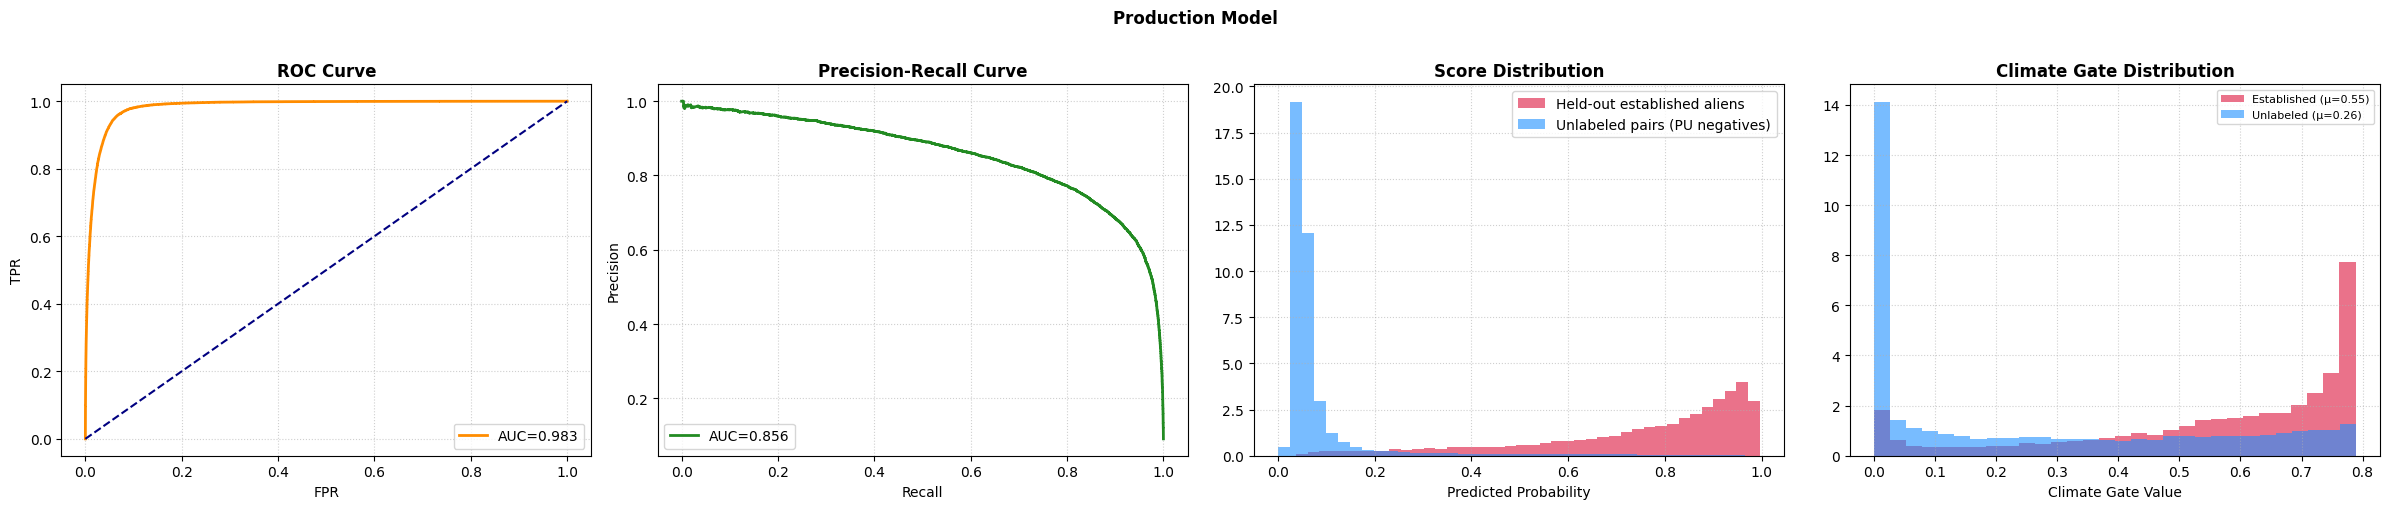

   📊 Saved to gnn_diagnostics_production_model.png


In [19]:
# ==============================================================================
# 12. EVALUATION DASHBOARD (4-panel)
# ==============================================================================
def plot_evaluation_dashboard(result, title='GNN Evaluation'):
    """Renders ROC, PR, score distribution, and gate calibration panels."""
    pos_probs  = result['pos_probs']
    neg_probs  = result['neg_probs']
    pos_gate   = result['pos_gate']
    neg_gate   = result['neg_gate']
    fpr, tpr   = result['fpr'], result['tpr']
    precision  = result['precision']
    recall     = result['recall']
    roc_auc    = result['roc_auc']
    pr_auc     = result['pr_auc']

    print(f"\n📊 {title}")
    print("=" * 60)
    print(f"   ROC-AUC : {roc_auc:.4f}  (Target > 0.80)")
    print(f"   PR-AUC  : {pr_auc:.4f}  (Target > 0.80)")
    print(f"   Pos mean: {pos_probs.mean():.4f} | Unlabeled mean: {neg_probs.mean():.4f}")
    _rk = result.get('rank_metrics') or {}
    if _rk:
        print(f"   Ranking : median held-out positive in top {_rk['rank_median_top_frac']:.1%} "
              f"| top-5% hit {_rk['rank_hit_top5pct']:.1%} | top-10% hit {_rk['rank_hit_top10pct']:.1%}")
    gate_sep = pos_gate.mean() - neg_gate.mean()
    marker   = "✅" if gate_sep > 0.05 else ("⚠️ " if gate_sep > 0 else "❌")
    print(f"   Gate sep: {gate_sep:+.3f} {marker}")
    print("=" * 60)

    fig, axes = plt.subplots(1, 4, figsize=(24, 5))

    axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC={roc_auc:.3f}')
    axes[0].plot([0,1],[0,1], 'navy', lw=1.5, linestyle='--')
    axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
    axes[0].set_title('ROC Curve', fontweight='bold')
    axes[0].legend(loc='lower right'); axes[0].grid(True, linestyle=':', alpha=0.6)

    axes[1].plot(recall, precision, color='forestgreen', lw=2, label=f'AUC={pr_auc:.3f}')
    axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
    axes[1].set_title('Precision-Recall Curve', fontweight='bold')
    axes[1].legend(loc='lower left'); axes[1].grid(True, linestyle=':', alpha=0.6)

    axes[2].hist(pos_probs, bins=40, alpha=0.6, color='crimson',
                 density=True, label='Held-out established aliens')
    axes[2].hist(neg_probs, bins=40, alpha=0.6, color='dodgerblue',
                 density=True, label='Unlabeled pairs (PU negatives)')
    axes[2].set_xlabel('Predicted Probability')
    axes[2].set_title('Score Distribution', fontweight='bold')
    axes[2].legend(); axes[2].grid(True, linestyle=':', alpha=0.6)

    axes[3].hist(pos_gate, bins=30, alpha=0.6, color='crimson',
                 density=True, label=f'Established (μ={pos_gate.mean():.2f})')
    axes[3].hist(neg_gate, bins=30, alpha=0.6, color='dodgerblue',
                 density=True, label=f'Unlabeled (μ={neg_gate.mean():.2f})')
    axes[3].set_xlabel('Climate Gate Value')
    axes[3].set_title('Climate Gate Distribution', fontweight='bold')
    axes[3].legend(fontsize=8); axes[3].grid(True, linestyle=':', alpha=0.6)

    plt.suptitle(title, fontweight='bold', y=1.01)
    plt.tight_layout()
    fname = f"gnn_diagnostics_{title.replace(' ','_').lower()}.png"
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"   📊 Saved to {fname}")


# Plot production model evaluation
plot_evaluation_dashboard(prod_result, 'Production Model')

In [20]:
# ==============================================================================
# DIAGNOSTICS: PU contamination, leakage size, and hard-negative proximity
# ==============================================================================
from sklearn.metrics import roc_auc_score
from collections import Counter

# ---- 1. What the OLD sampler would have drawn (it only excluded positives) ----
with torch.no_grad():
    _m  = 200_000
    _sp = torch.randint(0, num_species,   (_m,), device=DEVICE)
    _co = torch.randint(0, num_countries, (_m,), device=DEVICE)
    _pos_only = torch.zeros_like(exclude_mask); _pos_only[pos_sp, pos_co] = True
    _nat_only = torch.zeros_like(exclude_mask); _nat_only[native_ei[0], native_ei[1]] = True
    _old = has_any_signal[_sp] & ~_pos_only[_sp, _co]          # old rule
    _o_sp, _o_co = _sp[_old], _co[_old]
    print("1) Old negative rule (only established_in pairs excluded):")
    print(f"   drawn pairs already in GBIF presence : {presence_mat[_o_sp, _o_co].bool().float().mean():.1%}")
    print(f"   drawn pairs in native_ei             : {_nat_only[_o_sp, _o_co].float().mean():.1%}")
    print(f"   drawn pairs recorded anywhere        : {exclude_mask[_o_sp, _o_co].float().mean():.1%}")
    _n_sp, _n_co = sample_negative_edges_simple(50_000)
    print(f"   NEW sampler, recorded pairs drawn    : {exclude_mask[_n_sp, _n_co].float().mean():.1%}  (must be 0.0%)")

# ---- 2. Size of the feature leak: climate distance ALONE, leaky vs fixed ----
#   leaky = niche from the full range matrix, own pair included (old behaviour)
#   fixed = this split's niche with the held-out positives removed
def _clim_auc(stats, loo, p_sp, p_co, n_sp, n_co):
    with torch.no_grad():
        def _d(sp, co):
            m, s = stats.niche(sp, co, loo=loo)
            return ((m - co_climate_tensor[co]) / s).pow(2).sum(-1).sqrt().cpu().numpy()
        dp, dn = _d(p_sp, p_co), _d(n_sp, n_co)
    return roc_auc_score(np.r_[np.ones(len(dp)), np.zeros(len(dn))], -np.r_[dp, dn])

_vp_sp, _vp_co = prod_val_sp, prod_val_co
_vn_sp, _vn_co = prod_result['val_neg_sp'], prod_result['val_neg_co']
auc_leaky = _clim_auc(scan_stats,            False, _vp_sp, _vp_co, _vn_sp, _vn_co)
auc_fixed = _clim_auc(prod_result['stats'],  True,  _vp_sp, _vp_co, _vn_sp, _vn_co)
print(f"\n2) AUC of climate distance alone on validation pairs")
print(f"   leaky niche (own pair inside range) : {auc_leaky:.4f}")
print(f"   fixed niche (leave-one-out + masked) : {auc_fixed:.4f}   (should be lower)")

# ---- 3. Positive vs hard-negative proximity in climate space ----
with torch.no_grad():
    _st = prod_result['stats']
    _pm, _ps = _st.niche(prod_train_sp, prod_train_co)
    pos_m_dist = ((_pm - co_climate_tensor[prod_train_co]) / _ps).pow(2).sum(-1).sqrt().cpu().numpy()
    hard_neg_sp, hard_neg_co = sample_negative_edges_hard(
        prod_train_sp.size(0) * 5, _st, ref_pos_sp=prod_train_sp)
    _hm, _hs = _st.niche(hard_neg_sp, hard_neg_co)
    hard_m_dist = ((_hm - co_climate_tensor[hard_neg_co]) / _hs).pow(2).sum(-1).sqrt().cpu().numpy()
print(f"\n3) Positive m-dist:      mean={pos_m_dist.mean():.3f}  median={np.median(pos_m_dist):.3f}")
print(f"   Hard-negative m-dist: mean={hard_m_dist.mean():.3f}  median={np.median(hard_m_dist):.3f}")
zero_signal_mask = (sp_features.sum(dim=1) == 0)
print(f"   Zero-signal species among hard negatives: "
      f"{zero_signal_mask[hard_neg_sp].float().mean().item():.3f} "
      f"(all species: {zero_signal_mask.float().mean().item():.3f})")

# ---- 4. Tie / near-tie check in production val scores ----
rounded = np.round(np.concatenate([prod_result['pos_probs'], prod_result['neg_probs']]), 3)
print(f"\n4) Most common rounded val probabilities: {Counter(rounded).most_common(5)}")


1) Old negative rule (only established_in pairs excluded):
   drawn pairs already in GBIF presence : 6.6%
   drawn pairs in native_ei             : 6.6%
   drawn pairs recorded anywhere        : 6.6%
   NEW sampler, recorded pairs drawn    : 0.0%  (must be 0.0%)

2) AUC of climate distance alone on validation pairs
   leaky niche (own pair inside range) : 0.8079
   fixed niche (leave-one-out + masked) : 0.7930   (should be lower)

3) Positive m-dist:      mean=2.531  median=2.214
   Hard-negative m-dist: mean=3.531  median=3.479
   Zero-signal species among hard negatives: 0.337 (all species: 0.251)

4) Most common rounded val probabilities: [(np.float32(0.043), 5000), (np.float32(0.044), 4720), (np.float32(0.042), 4538), (np.float32(0.045), 4522), (np.float32(0.046), 4520)]


In [21]:
# ==============================================================================
# 12b. EXPORT STATIC HORIZON-SCANNING ARTIFACT
#
#    Saves everything needed to run execute_gnn_horizon_scan() later without
#    rerunning training. Note: EVERYTHING is moved to CPU before saving,
#    regardless of which device strategy Section 7 uses (fully-on-DEVICE or
#    CPU-resident lookups) — this is what caused your original crash, since
#    the previous export saved a mix of DEVICE and CPU tensors and reloading
#    on a machine/session with different GPU availability produced exactly
#    the "found at least two devices" error.
#
#    CHANGES FROM PREVIOUS VERSION:
#    - Added 'num_species' and 'has_any_signal' to the export dict. The
#      static scanner needs both: num_species to know how many candidates
#      exist without depending on any live variable, and has_any_signal to
#      exclude zero-evidence species (no structural degree, no presence
#      records) from the ranked output — these were the species producing
#      nonsensical, near-identical top scores in earlier inference runs.
#    - bio_opp_mat replaced with pos_opp_mat + neg_opp_mat (valence split).
#    - PU fix: sp_realized_mean/std and presence_mat are no longer saved.
#      Saved instead: range_mat + niche sums (RangeStats) and exclude_mask.
# ==============================================================================
print("💾 Exporting static horizon scanning static artifact...")

encoder.eval(); predictor.eval(); trade_encoder.eval(); country_ae.eval()
with torch.no_grad():
    final_sp_emb = encoder(sp_x_dict, train_edge_index_dict)['species'].cpu()
    final_co_lat = country_ae.encode(co_climate_tensor).cpu()

export_dict = {
    'predictor_state':     predictor.state_dict(),
    'trade_encoder_state': trade_encoder.state_dict(),
    'country_ae_state':    country_ae.state_dict(),

    # Precomputed tensors — all explicitly moved to CPU so the artifact
    # loads correctly on any machine, GPU or not, later
    'sp_emb':            final_sp_emb,
    'co_latent':         final_co_lat,
    'co_climate_tensor': co_climate_tensor.cpu(),
    'gate_sigma':        GATE_SIGMA,

    # Range data replaces the old per-species sp_realized_mean/std tables.
    # range_mat (bool), sp_n, sp_sum, sp_sq, g_mean, g_std rebuild RangeStats,
    # which gives the per-pair leave-one-out niche and trade routing.
    **scan_stats.state(),
    # Pairs recorded anywhere (never scan candidates).
    'exclude_mask':      exclude_mask.cpu(),

    # NEW — needed by the static scanner
    'num_species':     num_species,
    'has_any_signal':  has_any_signal.cpu(),

    # Lookup tensors needed by compute_trade_latent / biotic_opportunity_score
    # at inference time. FIX: previously this used `if 'X_cpu' in dir() else X`
    # to guess between a "CPU-resident" and "fully-on-DEVICE" strategy. But
    # Section 7 only ever implements the fully-on-DEVICE strategy in this
    # notebook — the `_cpu` names are never assigned anywhere, so `dir()`
    # was really just checking "did some earlier/other cell in this kernel
    # session happen to leave a stale variable with this name lying around".
    # If it had (e.g. from testing an alternate Section 7 strategy without
    # restarting the kernel), this checkpoint would silently save THOSE
    # stale tensors instead of the ones the model actually just trained on —
    # producing a static model whose predictions don't match live training.
    # Always reference the live, just-trained-against tensors directly.
    'trade_channels_tensor': trade_channels_tensor.cpu(),
    'co_trade_import': co_trade_import.cpu(),
    'pos_opp_mat': pos_opp_mat.cpu(),
    'neg_opp_mat': neg_opp_mat.cpu(),

    # Index maps needed to interpret species/country IDs at inference time
    'sp_to_idx': sp_to_idx, 'idx_to_sp': idx_to_sp,
    'co_to_idx': co_to_idx, 'idx_to_co': idx_to_co,
    'id_to_name': id_to_name,
}

torch.save(export_dict, 'horizon_scan_static.pt')
print("   ✅ Saved to horizon_scan_static.pt")

💾 Exporting static horizon scanning static artifact...
   ✅ Saved to horizon_scan_static.pt


In [22]:
# ==============================================================================
# 13. INFERENCE — HORIZON SCANNING
# ==============================================================================
INFERENCE_CHUNK = 2048

def execute_gnn_horizon_scan(target_country_name: str, top_n: int = 500) -> pd.DataFrame:
    """
    Score every species that is NOT recorded in target_country_name (SInAS
    native / alien / other, or GBIF presence) and has some signal, and return
    top_n ranked by invasion probability. This is the same candidate pool the
    negatives are drawn from in training. All tensors are on DEVICE.
    """
    if target_country_name not in co_to_idx:
        raise ValueError(f"'{target_country_name}' not found in spatial index.")

    encoder.eval(); predictor.eval(); trade_encoder.eval(); country_ae.eval()

    with torch.no_grad():
        co_lat = country_ae.encode(co_climate_tensor)
        sp_emb = encoder(sp_x_dict, train_edge_index_dict)['species']

    co_idx = co_to_idx[target_country_name]

    candidate_mask   = has_any_signal & ~exclude_mask[:, co_idx]
    candidate_tensor = candidate_mask.nonzero(as_tuple=True)[0]
    if candidate_tensor.numel() == 0:
        raise ValueError(f"No eligible candidate species for '{target_country_name}'.")
    country_tensor = torch.full((candidate_tensor.numel(),), co_idx,
                                dtype=torch.long, device=DEVICE)

    scores = []
    with torch.no_grad():
        for i in range(0, candidate_tensor.numel(), INFERENCE_CHUNK):
            chunk_sp = candidate_tensor[i:i + INFERENCE_CHUNK]
            chunk_co = country_tensor[i:i + INFERENCE_CHUNK]
            chunk_logits, _ = score_pairs(chunk_sp, chunk_co, sp_emb, co_lat,
                                          predictor, trade_encoder, scan_stats)
            scores.append(torch.sigmoid(chunk_logits))

    probs = torch.cat(scores).cpu().numpy()
    candidate_indices = candidate_tensor.tolist()

    df_scan = (
        pd.DataFrame([{
            'gbif_id':                  idx_to_sp[idx],
            'taxon_name':               id_to_name.get(idx_to_sp[idx],
                                                        f"GBIF:{idx_to_sp[idx]}"),
            'gnn_invasion_probability': float(p),
        } for idx, p in zip(candidate_indices, probs)])
        .sort_values('gnn_invasion_probability', ascending=False)
        .reset_index(drop=True)
        .head(top_n)
    )
    print(f"✅ GNN scan complete — {len(df_scan)} candidates ranked.")
    return df_scan


In [23]:
# ==============================================================================
# 14. GBIF VALIDATION
# ==============================================================================
def validate_horizon_threats_gbif(
    risk_df: pd.DataFrame,
    gbif_country_code: str,
    species_to_validate: int = 100,
    sleep_time: float = 0.2,
) -> pd.DataFrame:
    """
    Validates GNN predictions against live GBIF occurrence counts.
    Keeps only species with zero confirmed occurrences in the target country.
    """
    if not gbif_country_code:
        print("⚠️ No GBIF country code provided. Skipping validation.")
        return risk_df.head(species_to_validate)

    print(f"🔍 Validating via GBIF for '{gbif_country_code}'...")
    validated_records = []
    api_calls_made = 0; discarded_present = 0; errors_hit = 0

    with tqdm(total=species_to_validate, desc="Verified absent threats",
              unit="species") as pbar:
        for _, row in risk_df.iterrows():
            if len(validated_records) >= species_to_validate:
                print(f"\n🎯 Top {species_to_validate} verified threats secured.")
                break

            if api_calls_made > 0:
                time.sleep(sleep_time)
            api_calls_made += 1

            taxon_key    = int(row['gbif_id'])
            current_name = str(row['taxon_name'])

            try:
                if current_name.startswith("GBIF:"):
                    resolved_name = (gbif_species.name_usage(key=taxon_key)
                                     .get('scientificName',
                                          f"Unresolved ID: {taxon_key}"))
                else:
                    resolved_name = current_name

                occurrence_count = (
                    occurrences.search(taxonKey=taxon_key,
                                       country=gbif_country_code, limit=0)
                    .get('count', 0))

                if occurrence_count == 0:
                    new_row = row.to_dict()
                    new_row['taxon_name']            = resolved_name
                    new_row['gbif_matched_name']     = resolved_name
                    new_row['gbif_occurrence_count'] = occurrence_count
                    new_row['gbif_taxon_key']        = taxon_key
                    validated_records.append(new_row)
                    pbar.update(1)
                else:
                    discarded_present += 1

                pbar.set_postfix({'API calls': api_calls_made,
                                  'Already present': discarded_present,
                                  'Errors': errors_hit})

            except Exception as e:
                errors_hit += 1
                time.sleep(sleep_time * 5)
                err_row = row.to_dict()
                err_row['gbif_matched_name']     = f"FETCH ERROR: {str(e)[:40]}"
                err_row['gbif_occurrence_count'] = -1
                err_row['gbif_taxon_key']        = taxon_key
                validated_records.append(err_row)
                pbar.update(1)

    return pd.DataFrame(validated_records).reset_index(drop=True)

In [24]:
# ==============================================================================
# RUN — BELGIUM
# ==============================================================================
belgium_gnn_rankings = execute_gnn_horizon_scan('Belgium', top_n=500)

belgium_validated = validate_horizon_threats_gbif(
    belgium_gnn_rankings,
    gbif_country_code='BE',
    species_to_validate=100,
    sleep_time=1,
)

belgium_validated.head(20)

✅ GNN scan complete — 500 candidates ranked.
🔍 Validating via GBIF for 'BE'...


Verified absent threats:   0%|          | 0/100 [00:00<?, ?species/s]


🎯 Top 100 verified threats secured.


,gbif_id,taxon_name,gnn_invasion_probability,gbif_matched_name,gbif_occurrence_count,gbif_taxon_key
0,1420881,Taeniothrips inconsequens,0.991403,Taeniothrips inconsequens,0,1420881
1,2913365,Galium trifidum,0.989762,Galium trifidum,0,2913365
2,2010165,Orthocephalus saltator,0.989110,Orthocephalus saltator,0,2010165
3,7814874,Myosotis sparsiflora,0.988975,Myosotis sparsiflora,0,7814874
4,2999072,Rubus cochinchinensis,0.988907,Rubus cochinchinensis,0,2999072
5,3021120,Prunus salicina,0.988325,Prunus salicina,0,3021120
6,2049681,Adelges piceae,0.988282,Adelges piceae,0,2049681
7,4149617,Hordeum brevisubulatum,0.987935,Hordeum brevisubulatum,0,4149617
8,9123250,Lactuca tatarica,0.987873,Lactuca tatarica,0,9123250
9,1048497,Diabrotica virgifera,0.986951,Diabrotica virgifera,0,1048497


In [40]:
#build model bundle for live inference from trainied model

def build_live_bundle(
    encoder,
    predictor,
    trade_encoder,
    country_ae,
    sp_x_dict,
    train_edge_index_dict,
    co_climate_tensor,
    scan_stats,
    trade_channels_tensor,
    co_trade_import,
    pos_opp_mat,
    neg_opp_mat,
    sp_to_idx,
    co_to_idx,
    id_to_name,
    idx_to_sp,
    has_any_signal,
    exclude_mask,
):
    """Builds a scanner bundle from live notebook memory, including candidate selection

    and name lookup metadata.
    """
    was_training = encoder.training
    encoder.eval()
    predictor.eval()
    trade_encoder.eval()
    country_ae.eval()

    with torch.no_grad():
        sp_emb = encoder(sp_x_dict, train_edge_index_dict)["species"]
        co_latent = country_ae.encode(co_climate_tensor)

    if was_training:
        encoder.train()

    bundle = {
        "sp_emb": sp_emb,
        "co_latent": co_latent,
        "co_climate_tensor": co_climate_tensor,
        "range_stats": scan_stats,
        "trade_channels_tensor": trade_channels_tensor,
        "co_trade_import": co_trade_import,
        "pos_opp_mat": pos_opp_mat,
        "neg_opp_mat": neg_opp_mat,
        "sp_to_idx": sp_to_idx,
        "co_to_idx": co_to_idx,
        "id_to_name": id_to_name,
        "idx_to_sp": idx_to_sp,
        "has_any_signal": has_any_signal,
        "exclude_mask": exclude_mask,
    }
    return predictor, trade_encoder, bundle

In [ ]:
#Combined attribution + prediction + MC error calculation definitions

def _forward_from_leaves_full(
    predictor,
    trade_encoder,
    realized_mean,
    realized_std,
    target_climate,
    import_vec,
    export_vec,
    bio_opp,
    sp_emb,
    co_latent,
):
    """Re-implements model forward pass with leaf gradients enabled across all inputs."""
    z_diff = (realized_mean - target_climate) / (realized_std + 1e-6)
    abs_z = z_diff.abs()
    m_dist = z_diff.pow(2).sum(dim=-1, keepdim=True).sqrt()

    gate = predictor.climate_gate(torch.cat([m_dist, z_diff.pow(2)], dim=-1))

    topo_out = predictor.topo_stream(torch.cat([sp_emb, co_latent], dim=-1)) * gate
    niche_out = predictor.niche_stream(
        torch.cat([realized_mean, target_climate, abs_z], dim=-1)
    )
    suit_out = predictor.suitability_stream(
        torch.cat([realized_mean, target_climate], dim=-1)
    )
    trade_latent = trade_encoder(import_vec, export_vec)
    trade_out = predictor.trade_proj(trade_latent)
    bio_out = predictor.bio_opp_proj(bio_opp)

    logits = predictor.classifier(
        torch.cat([topo_out, niche_out, suit_out, trade_out, bio_out], dim=-1)
    ).squeeze(-1)
    return logits


def explain_prediction_attributions_only(
    scanner_data: tuple,
    gbif_id: int,
    target_country: str,
    climate_feature_names: list,
    trade_channel_names: list,
    n_steps: int = 50,
    baseline: str = "mean",
    expand_embeddings: bool = False,
) -> dict:
    """Calculates Integrated Gradients attribution weights across all input parameter streams."""
    predictor, trade_encoder, ckpt = scanner_data
    device = ckpt["sp_emb"].device

    sp_idx = torch.as_tensor([ckpt["sp_to_idx"][gbif_id]], device=device)
    co_idx = torch.as_tensor([ckpt["co_to_idx"][target_country]], device=device)

    range_stats = ckpt["range_stats"]
    realized_mean, realized_std = range_stats.niche(sp_idx, co_idx)
    realized_mean, realized_std = realized_mean.detach(), realized_std.detach()
    target_climate = ckpt["co_climate_tensor"][co_idx].detach()

    export_vec = trade_export_vector(
        ckpt["trade_channels_tensor"], range_stats.P, sp_idx, co_idx
    ).detach()
    import_vec = ckpt["co_trade_import"][co_idx].detach()

    pos_opp = ckpt["pos_opp_mat"][sp_idx, co_idx].detach()
    neg_opp = ckpt["neg_opp_mat"][sp_idx, co_idx].detach()
    bio_opp = torch.stack([pos_opp, neg_opp], dim=-1).detach()

    sp_e = ckpt["sp_emb"][sp_idx].detach()
    co_l = ckpt["co_latent"][co_idx].detach()

    actual = [
        realized_mean,
        realized_std,
        target_climate,
        import_vec,
        export_vec,
        bio_opp,
        sp_e,
        co_l,
    ]
    names = [
        "realized_mean",
        "realized_std",
        "target_climate",
        "import_vec",
        "export_vec",
        "bio_opp",
        "sp_e",
        "co_l",
    ]

    if baseline == "zero":
        base = [torch.zeros_like(t) for t in actual]
    elif baseline == "mean":
        all_sp_mean = ckpt["range_stats"].sp_sum / ckpt[
            "range_stats"
        ].sp_n.clamp(min=1)
        mean_niche_m = all_sp_mean.mean(dim=0, keepdim=True)
        mean_niche_s = ckpt["range_stats"].g_std
        base = [
            mean_niche_m.to(device),
            mean_niche_s.to(device),
            ckpt["co_climate_tensor"].mean(dim=0, keepdim=True),
            ckpt["co_trade_import"].mean(dim=0, keepdim=True),
            torch.zeros_like(export_vec),
            torch.zeros_like(bio_opp),
            ckpt["sp_emb"].mean(dim=0, keepdim=True),
            ckpt["co_latent"].mean(dim=0, keepdim=True),
        ]
    else:
        raise ValueError("baseline must be 'zero' or 'mean'")

    grads_accum = [torch.zeros_like(t) for t in actual]
    for step in range(1, n_steps + 1):
        alpha = step / n_steps
        interp = [
            (b + alpha * (a - b)).clone().requires_grad_(True)
            for a, b in zip(actual, base)
        ]
        logit = _forward_from_leaves_full(
            predictor, trade_encoder, *interp
        )
        grads = torch.autograd.grad(logit, interp)
        for acc, g in zip(grads_accum, grads):
            acc += g

    attributions = {}
    for name, g, a, b in zip(names, grads_accum, actual, base):
        attributions[name] = (
            ((g / n_steps) * (a - b)).squeeze(0).detach().cpu()
        )

    attr_vals = {}

    for i, fname in enumerate(climate_feature_names):
        attr_vals[f"attr_climate_target_{fname}"] = attributions[
            "target_climate"
        ][i].item()
        attr_vals[f"attr_climate_niche_mean_{fname}"] = attributions[
            "realized_mean"
        ][i].item()
        attr_vals[f"attr_climate_niche_std_{fname}"] = attributions[
            "realized_std"
        ][i].item()

    for i, cname in enumerate(trade_channel_names):
        attr_vals[f"attr_trade_import_{cname}"] = attributions["import_vec"][
            i
        ].item()
        attr_vals[f"attr_trade_export_{cname}"] = attributions["export_vec"][
            i
        ].item()

    attr_vals["attr_biotic_opp_positive"] = attributions["bio_opp"][0].item()
    attr_vals["attr_biotic_opp_negative"] = attributions["bio_opp"][1].item()

    if expand_embeddings:
        for i in range(sp_e.shape[1]):
            attr_vals[f"attr_gnn_sp_dim_{i}"] = attributions["sp_e"][i].item()
        for i in range(co_l.shape[1]):
            attr_vals[f"attr_co_latent_dim_{i}"] = attributions["co_l"][i].item()
    else:
        attr_vals["attr_relational_ecology_species_gnn"] = attributions[
            "sp_e"
        ].sum().item()
        attr_vals["attr_relational_ecology_country_latent"] = attributions[
            "co_l"
        ].sum().item()

    return attr_vals


def score_pairs_with_mc_uncertainty(
    predictor,
    trade_encoder,
    sp_emb,
    co_latent,
    sp_idx,
    co_idx,
    realized_mean,
    realized_std,
    co_climate_tensor,
    trade_latent,
    bio_opp,
    n_mc_samples: int = 30,
):
    """Performs stochastic passes with active dropout to compute mean probability, std, and SE."""
    predictor.train()
    trade_encoder.train()

    mc_probs = []
    with torch.no_grad():
        for _ in range(n_mc_samples):
            logits, _ = predictor(
                sp_emb=sp_emb,
                co_latent=co_latent,
                sp_idx=sp_idx,
                co_idx=co_idx,
                realized_mean=realized_mean,
                realized_std=realized_std,
                co_climate_tensor=co_climate_tensor,
                trade_latent=trade_latent,
                bio_opp=bio_opp,
            )
            mc_probs.append(torch.sigmoid(logits))

    predictor.eval()
    trade_encoder.eval()

    stacked_probs = torch.stack(mc_probs, dim=0)
    mean_prob = stacked_probs.mean(dim=0)
    std_prob = stacked_probs.std(dim=0)
    se_prob = std_prob / (n_mc_samples**0.5)

    return mean_prob, std_prob, se_prob


def execute_attribution_horizon_scan(
    target_country: str,
    scanner_data: tuple,
    climate_feature_names: list,
    trade_channel_names: list,
    top_n: int = 50,
    gbif_country_code: str | None = None,
    n_steps: int = 50,
    n_mc_samples: int = 30,
    expand_embeddings: bool = False,
    sleep_time: float = 0.2,
) -> pd.DataFrame:
    """Executes a scan with Monte Carlo Dropout uncertainty and individual attribution weights."""
    predictor, trade_encoder, ckpt = scanner_data

    if target_country not in ckpt["co_to_idx"]:
        raise ValueError(
            f"'{target_country}' not found in checkpoint country index."
        )

    co_idx_val = ckpt["co_to_idx"][target_country]
    device = ckpt["sp_emb"].device

    candidate_mask = (
        ckpt["has_any_signal"].bool()
        & ~ckpt["exclude_mask"][:, co_idx_val].bool()
    )
    candidate_tensor = torch.where(candidate_mask)[0].to(device)

    if candidate_tensor.numel() == 0:
        raise ValueError(
            f"No eligible candidate species found for '{target_country}'."
        )

    country_tensor = torch.full(
        (candidate_tensor.numel(),), co_idx_val, dtype=torch.long, device=device
    )

    mean_scores, std_scores, se_scores = [], [], []
    chunk_size = 2048
    range_stats = ckpt["range_stats"]

    print(
        f"🎲 Scoring candidate pairs with Monte Carlo Dropout ({n_mc_samples} passes)..."
    )
    for start in range(0, candidate_tensor.numel(), chunk_size):
        chunk_sp = candidate_tensor[start : start + chunk_size]
        chunk_co = country_tensor[start : start + chunk_size]

        export_vec = trade_export_vector(
            ckpt["trade_channels_tensor"], range_stats.P, chunk_sp, chunk_co
        )
        import_vec = ckpt["co_trade_import"][chunk_co]
        realized_mean, realized_std = range_stats.niche(chunk_sp, chunk_co)
        trade_latent = trade_encoder(import_vec, export_vec)
        bio_opp = torch.stack(
            [
                ckpt["pos_opp_mat"][chunk_sp, chunk_co],
                ckpt["neg_opp_mat"][chunk_sp, chunk_co],
            ],
            dim=-1,
        )

        mean_p, std_p, se_p = score_pairs_with_mc_uncertainty(
            predictor=predictor,
            trade_encoder=trade_encoder,
            sp_emb=ckpt["sp_emb"],
            co_latent=ckpt["co_latent"],
            sp_idx=chunk_sp,
            co_idx=chunk_co,
            realized_mean=realized_mean,
            realized_std=realized_std,
            co_climate_tensor=ckpt["co_climate_tensor"],
            trade_latent=trade_latent,
            bio_opp=bio_opp,
            n_mc_samples=n_mc_samples,
        )

        mean_scores.append(mean_p)
        std_scores.append(std_p)
        se_scores.append(se_p)

    probs = torch.cat(mean_scores).cpu().numpy()
    stds = torch.cat(std_scores).cpu().numpy()
    ses = torch.cat(se_scores).cpu().numpy()
    cand_indices = candidate_tensor.tolist()

    df_ranked = (
        pd.DataFrame(
            {
                "gbif_id": [ckpt["idx_to_sp"][idx] for idx in cand_indices],
                "taxon_name": [
                    ckpt["id_to_name"].get(
                        ckpt["idx_to_sp"][idx], f"GBIF:{ckpt['idx_to_sp'][idx]}"
                    )
                    for idx in cand_indices
                ],
                "target_country": target_country,
                "invasion_probability": probs,
                "invasion_probability_std": stds,
                "invasion_probability_se": ses,
            }
        )
        .sort_values("invasion_probability", ascending=False)
        .reset_index(drop=True)
    )

    if gbif_country_code:
        verified_records = []
        already_present = 0
        errors = 0
        api_calls = 0

        print(
            f"🔍 Verifying candidates against live GBIF records for '{gbif_country_code}'..."
        )
        pool_size = min(len(df_ranked), top_n * 5)

        for _, row in tqdm(
            df_ranked.head(pool_size).iterrows(),
            total=pool_size,
            desc="GBIF Checking",
        ):
            if len(verified_records) >= top_n:
                break

            if api_calls > 0:
                time.sleep(sleep_time)

            taxon_key = int(row["gbif_id"])
            api_calls += 1

            try:
                occ_cnt = occurrences.search(
                    taxonKey=taxon_key, country=gbif_country_code, limit=0
                ).get("count", 0)

                if occ_cnt == 0:
                    v_row = row.to_dict()
                    v_row["gbif_occurrence_count"] = 0
                    verified_records.append(v_row)
                else:
                    already_present += 1
            except Exception:
                errors += 1

        df_ranked = pd.DataFrame(verified_records).reset_index(drop=True)
    else:
        df_ranked = df_ranked.head(top_n)

    attributions_list = []
    top_drivers = []
    top_suppressors = []

    print(
        f"🔬 Computing feature attributions for top {len(df_ranked)} predictions..."
    )
    for _, row in tqdm(
        df_ranked.iterrows(), total=len(df_ranked), desc="Attributing"
    ):
        attrs = explain_prediction_attributions_only(
            scanner_data=scanner_data,
            gbif_id=int(row["gbif_id"]),
            target_country=target_country,
            climate_feature_names=climate_feature_names,
            trade_channel_names=trade_channel_names,
            n_steps=n_steps,
            expand_embeddings=expand_embeddings,
        )

        attributions_list.append(attrs)

        pos_attrs = {k: v for k, v in attrs.items() if v > 0}
        neg_attrs = {k: v for k, v in attrs.items() if v < 0}

        driver = (
            max(pos_attrs.items(), key=lambda x: x[1])[0] if pos_attrs else "None"
        )
        suppressor = (
            min(neg_attrs.items(), key=lambda x: x[1])[0] if neg_attrs else "None"
        )

        top_drivers.append(driver.replace("attr_", ""))
        top_suppressors.append(suppressor.replace("attr_", ""))

    df_ranked["top_driver"] = top_drivers
    df_ranked["top_suppressor"] = top_suppressors

    df_attr = pd.DataFrame(attributions_list)

    final_df = pd.concat([df_ranked, df_attr], axis=1)

    # Guarantee gbif_id is explicitly the first column
    cols = ["gbif_id"] + [c for c in final_df.columns if c != "gbif_id"]
    return final_df[cols]

In [44]:
#Execute horizon scan with attributions and Monte Carlo uncertainty, optionally validating against GBIF

# 1. Package live model objects into the scanner bundle
live_scanner_data = build_live_bundle(
    encoder,
    predictor,
    trade_encoder,
    country_ae,
    sp_x_dict,
    train_edge_index_dict,
    co_climate_tensor,
    scan_stats,
    trade_channels_tensor,
    co_trade_import,
    pos_opp_mat,
    neg_opp_mat,
    sp_to_idx,
    co_to_idx,
    id_to_name,
    idx_to_sp,
    has_any_signal,
    exclude_mask,
)

# 2. Extract feature names
CLIMATE_FEATURE_NAMES = list(df_climate.columns.drop(country_col))
TRADE_CHANNEL_NAMES = list(ECOLOGICAL_TRADE_MAPPING.keys())

# 3. Run scan with Monte Carlo SE uncertainty and ALL numerical feature attributions
# (Set expand_embeddings=True if you also want 96 separate columns for the raw GNN/Latent dimensions)
results_df = execute_attribution_horizon_scan(
    target_country="Belgium",
    scanner_data=live_scanner_data,  # or scanner_data from load_static_scanner
    climate_feature_names=CLIMATE_FEATURE_NAMES,
    trade_channel_names=TRADE_CHANNEL_NAMES,
    top_n=50,
    gbif_country_code="BE",  # Set None to skip live GBIF lookups
    n_mc_samples=30,
    expand_embeddings=False,
)

# 4. Export EVERYTHING to CSV (contains gbif_id, scores, SE, and ALL numerical attr_* columns)
csv_filename = "belgium_horizon_scan_explained.csv"
results_df.to_csv(csv_filename, index=False)
print(
    f"✅ Saved complete dataset ({results_df.shape[0]} rows x {results_df.shape[1]} columns) to '{csv_filename}'\n"
)

# 5. VERIFY ALL NUMERICAL ATTRIBUTION COLUMNS
attr_cols = [c for c in results_df.columns if c.startswith("attr_")]

print(f"📊 Total Numerical Attribution Columns Exported: {len(attr_cols)}")
print("=" * 75)
for col in attr_cols:
    print(f"  • {col}")
print("=" * 75)

# Preview the actual numerical attribution values for the top 5 predictions
results_df[["gbif_id", "taxon_name", "invasion_probability", "invasion_probability_se"] + attr_cols].head(
    5
)

🎲 Scoring candidate pairs with Monte Carlo Dropout (30 passes)...
🔍 Verifying candidates against live GBIF records for 'BE'...


GBIF Checking:   0%|          | 0/250 [00:00<?, ?it/s]

🔬 Computing feature attributions for top 50 predictions...


Attributing:   0%|          | 0/50 [00:00<?, ?it/s]

✅ Saved complete dataset (50 rows x 44 columns) to 'belgium_horizon_scan_explained.csv'

📊 Total Numerical Attribution Columns Exported: 35
  • attr_climate_target_latitude
  • attr_climate_niche_mean_latitude
  • attr_climate_niche_std_latitude
  • attr_climate_target_longitude
  • attr_climate_niche_mean_longitude
  • attr_climate_niche_std_longitude
  • attr_climate_target_mean_temperature
  • attr_climate_niche_mean_mean_temperature
  • attr_climate_niche_std_mean_temperature
  • attr_climate_target_temperature_seasonality
  • attr_climate_niche_mean_temperature_seasonality
  • attr_climate_niche_std_temperature_seasonality
  • attr_climate_target_frost_days
  • attr_climate_niche_mean_frost_days
  • attr_climate_niche_std_frost_days
  • attr_climate_target_precipitation
  • attr_climate_niche_mean_precipitation
  • attr_climate_niche_std_precipitation
  • attr_climate_target_aridity_index
  • attr_climate_niche_mean_aridity_index
  • attr_climate_niche_std_aridity_index
  • attr_t

,gbif_id,taxon_name,invasion_probability,invasion_probability_se,attr_climate_target_latitude,attr_climate_niche_mean_latitude,attr_climate_niche_std_latitude,attr_climate_target_longitude,attr_climate_niche_mean_longitude,attr_climate_niche_std_longitude,...,attr_trade_import_terrestrial_pets,attr_trade_export_terrestrial_pets,attr_trade_import_agri_hitchhikers,attr_trade_export_agri_hitchhikers,attr_trade_import_microbial_risk,attr_trade_export_microbial_risk,attr_biotic_opp_positive,attr_biotic_opp_negative,attr_relational_ecology_species_gnn,attr_relational_ecology_country_latent
0,1420881,Taeniothrips inconsequens,0.983081,0.004370,-0.363391,0.196931,0.004218,0.019814,0.169451,-0.008774,...,-0.455881,-0.515742,-1.014503,3.883926,2.029817,-4.213374,0.096508,0.969310,4.238311,0.013598
1,2077518,Acyrthosiphon caraganae,0.981962,0.002434,-0.413582,0.252937,0.002966,0.025852,0.185555,-0.015944,...,-0.384686,-1.019791,-0.979179,4.522470,2.183306,-4.308893,0.049257,1.269750,3.355383,0.015851
2,2891583,Geranium sibiricum,0.981375,0.003228,-0.571590,0.410579,-0.068179,0.005148,0.166570,-0.006377,...,-0.418173,-0.597777,-0.898252,2.936144,1.741912,-2.325224,0.050212,1.160388,3.654945,0.010921
3,1048497,Diabrotica virgifera,0.981206,0.001956,-0.388333,0.182428,0.002471,0.026448,0.093698,-0.021979,...,-0.470051,-0.804949,-0.854655,1.748382,1.737818,-1.597280,0.095887,0.996695,4.064325,0.006387
4,2010165,Orthocephalus saltator,0.981121,0.002484,-0.397836,0.250033,0.000916,0.026788,0.147376,-0.021492,...,-0.299606,-1.607847,-0.700579,3.539708,1.662580,-1.970556,0.087817,1.164483,3.907097,0.004876


In [26]:
#Attribution of prediction workflow (definitions)

def build_live_bundle(
    encoder, predictor, trade_encoder, country_ae,
    sp_x_dict, train_edge_index_dict,
    co_climate_tensor, range_stats,
    trade_channels_tensor, co_trade_import, pos_opp_mat, neg_opp_mat,
    sp_to_idx, co_to_idx,
):
    """
    Builds a (predictor, trade_encoder, bundle) tuple from whatever's
    currently live in the notebook's namespace — mirrors load_static_scanner()'s
    return shape exactly, so explain_prediction()/print_explanation() work
    unchanged on either. Doesn't move anything to a different device or
    mutate any module's .eval()/.train() state permanently — computation
    happens wherever your live tensors already live (GPU or CPU).
    """
    was_training = encoder.training
    encoder.eval(); predictor.eval(); trade_encoder.eval(); country_ae.eval()
    with torch.no_grad():
        sp_emb    = encoder(sp_x_dict, train_edge_index_dict)['species']
        co_latent = country_ae.encode(co_climate_tensor)
    if was_training:
        encoder.train()   # restore, in case you're calling this mid-training-loop

    bundle = {
        'sp_emb': sp_emb, 'co_latent': co_latent,
        'co_climate_tensor': co_climate_tensor,
        'range_stats': range_stats,
        'trade_channels_tensor': trade_channels_tensor,
        'co_trade_import': co_trade_import,
        'pos_opp_mat': pos_opp_mat, 'neg_opp_mat': neg_opp_mat,
        'sp_to_idx': sp_to_idx, 'co_to_idx': co_to_idx,
    }
    return predictor, trade_encoder, bundle

def _forward_from_leaves(predictor, trade_encoder, realized_mean, realized_std,
                          climate_t, imp_v, exp_v, bio, spe, col):
    """Re-implements NicheMatchingPredictor.forward but takes each semantically-named
    input as an explicit leaf tensor, and (unlike training) does NOT detach the
    climate_gate input — for explanation we want gradients to flow through every
    real computational path, including the climate->gate->topology path."""
    z_diff = (realized_mean - climate_t) / realized_std
    abs_z  = z_diff.abs()
    m_dist = z_diff.pow(2).sum(dim=-1, keepdim=True).sqrt()
    gate   = predictor.climate_gate(torch.cat([m_dist, z_diff.pow(2)], dim=-1))  # no .detach()

    topo_out  = predictor.topo_stream(torch.cat([spe, col], dim=-1)) * gate
    niche_out = predictor.niche_stream(torch.cat([realized_mean, climate_t, abs_z], dim=-1))
    suit_out  = predictor.suitability_stream(torch.cat([realized_mean, climate_t], dim=-1))
    trade_latent = trade_encoder(imp_v, exp_v)
    trade_out = predictor.trade_proj(trade_latent)
    bio_out   = predictor.bio_opp_proj(bio)

    logits = predictor.classifier(
        torch.cat([topo_out, niche_out, suit_out, trade_out, bio_out], dim=-1)
    ).squeeze(-1)
    return logits


def explain_prediction(
    scanner_data: tuple,          # (predictor, trade_encoder, ckpt) from load_static_scanner
    gbif_id: int,
    target_country: str,
    climate_feature_names: list,  # e.g. list(df_climate.columns.drop('location'))
    trade_channel_names: list,    # e.g. list(ECOLOGICAL_TRADE_MAPPING.keys())
    n_steps: int = 50,
    baseline: str = "mean",       # "mean" = compare vs. an average country/species; "zero" = compare vs. no signal at all
):
    """
    Integrated Gradients attribution for one (species, country) pair.
    Returns per-feature contributions to the pre-sigmoid logit, broken down
    into: each climate axis, each trade channel (import + export separately),
    biotic opportunity (positive and negative valence, separately), and the
    two "relational" (GNN / country-latent) blocks.

    Attributions sum (approximately) to actual_logit - baseline_logit — this
    is the IG "completeness" property, and the returned completeness_gap
    tells you exactly how good that approximation was (should be small;
    increase n_steps if it isn't).
    """
    predictor, trade_encoder, ckpt = scanner_data
    device = ckpt["sp_emb"].device

    sp_idx = torch.as_tensor([ckpt["sp_to_idx"][gbif_id]], device=device)
    co_idx = torch.as_tensor([ckpt["co_to_idx"][target_country]], device=device)

    # ---- Assemble the actual leaf values for this pair ----
    # Per-pair leave-one-out niche and trade routing (same functions as training)
    range_stats = ckpt["range_stats"]
    realized_mean, realized_std = range_stats.niche(sp_idx, co_idx)
    realized_mean, realized_std = realized_mean.detach(), realized_std.detach()
    target_climate = ckpt["co_climate_tensor"][co_idx].detach()

    export_vec = trade_export_vector(
        ckpt["trade_channels_tensor"], range_stats.P, sp_idx, co_idx).detach()
    import_vec = ckpt["co_trade_import"][co_idx].detach()

    pos_opp = ckpt["pos_opp_mat"][sp_idx, co_idx].detach()
    neg_opp = ckpt["neg_opp_mat"][sp_idx, co_idx].detach()
    bio_opp = torch.stack([pos_opp, neg_opp], dim=-1)   # (1, 2)

    sp_e = ckpt["sp_emb"][sp_idx].detach()
    co_l = ckpt["co_latent"][co_idx].detach()

    actual  = [target_climate, import_vec, export_vec, bio_opp, sp_e, co_l]
    names   = ["climate", "trade_import", "trade_export", "bio_opp", "rel_species", "rel_country"]

    # ---- Baseline: "what if this pair looked like an average pair?" ----
    if baseline == "zero":
        base = [torch.zeros_like(t) for t in actual]
    elif baseline == "mean":
        base = [
            ckpt["co_climate_tensor"].mean(dim=0, keepdim=True),
            ckpt["co_trade_import"].mean(dim=0, keepdim=True),
            torch.zeros_like(export_vec),   # "no export exposure at all" is the natural zero-point for trade
            torch.zeros_like(bio_opp),      # "no biotic opportunity at all"
            ckpt["sp_emb"].mean(dim=0, keepdim=True),
            ckpt["co_latent"].mean(dim=0, keepdim=True),
        ]
    else:
        raise ValueError("baseline must be 'zero' or 'mean'")

    # ---- Integrated Gradients: average gradient along the straight-line path
    #      from baseline to actual, times (actual - baseline) ----
    grads_accum = [torch.zeros_like(t) for t in actual]
    for step in range(1, n_steps + 1):
        alpha = step / n_steps
        interp = [(b + alpha * (a - b)).clone().requires_grad_(True)
                  for a, b in zip(actual, base)]
        logit = _forward_from_leaves(predictor, trade_encoder, realized_mean, realized_std, *interp)
        grads = torch.autograd.grad(logit, interp)
        for acc, g in zip(grads_accum, grads):
            acc += g

    attributions = {}
    for name, g, a, b in zip(names, grads_accum, actual, base):
        attributions[name] = ((g / n_steps) * (a - b)).squeeze(0).detach().cpu()

    with torch.no_grad():
        actual_logit   = _forward_from_leaves(predictor, trade_encoder, realized_mean, realized_std, *actual).item()
        baseline_logit = _forward_from_leaves(predictor, trade_encoder, realized_mean, realized_std, *base).item()

    # ---- Expand into named, human-readable features ----
    result = {}
    for i, fname in enumerate(climate_feature_names):
        result[f"climate: {fname}"] = attributions["climate"][i].item()
    for i, cname in enumerate(trade_channel_names):
        result[f"trade import: {cname}"] = attributions["trade_import"][i].item()
        result[f"trade export: {cname}"] = attributions["trade_export"][i].item()
    result["biotic opportunity (positive: resource/mutualism)"] = attributions["bio_opp"][0].item()
    result["biotic opportunity (negative: enemy/competition)"]  = attributions["bio_opp"][1].item()
    result["relational ecology (species graph embedding)"] = attributions["rel_species"].sum().item()
    result["relational ecology (country climate latent)"]  = attributions["rel_country"].sum().item()

    return {
        "attributions": dict(sorted(result.items(), key=lambda kv: -abs(kv[1]))),
        "baseline_logit": baseline_logit,
        "actual_logit": actual_logit,
        "predicted_prob": torch.sigmoid(torch.tensor(actual_logit)).item(),
        "baseline_prob": torch.sigmoid(torch.tensor(baseline_logit)).item(),
        "completeness_gap": (actual_logit - baseline_logit) - sum(result.values()),
    }


def print_explanation(explanation, top_k=12):
    print(f"Predicted probability: {explanation['predicted_prob']:.3f} "
          f"(baseline: {explanation['baseline_prob']:.3f})")
    print(f"Completeness check (should be near 0): {explanation['completeness_gap']:+.4f}\n")
    print(f"{'Feature':45s} {'Attribution (logit units)':>25s}")
    print("-" * 72)
    for name, val in list(explanation["attributions"].items())[:top_k]:
        bar = "█" * int(min(abs(val) * 8, 30))
        sign = "+" if val >= 0 else "-"
        print(f"{name:45s} {val:+8.4f}  {sign}{bar}")

In [27]:
# On a machine with the trained objects still live in memory (right after
# cell 16, or anywhere later in the same kernel session):
live_scanner_data = build_live_bundle(
    encoder, predictor, trade_encoder, country_ae,
    sp_x_dict, train_edge_index_dict,
    co_climate_tensor, scan_stats,
    trade_channels_tensor, co_trade_import, pos_opp_mat, neg_opp_mat,
    sp_to_idx, co_to_idx,
)

CLIMATE_FEATURE_NAMES = list(df_climate.columns.drop(country_col))   # the 7 climate variables, in the same order used to build co_climate_tensor
TRADE_CHANNEL_NAMES   = list(ECOLOGICAL_TRADE_MAPPING.keys())        # ['flora_and_timber', 'aquatic_fauna', ...]

# Identical downstream call either way:
explanation = explain_prediction(
    live_scanner_data,        # or static_scanner_data
    gbif_id=3112887,
    target_country="Belgium",
    climate_feature_names=CLIMATE_FEATURE_NAMES,
    trade_channel_names=TRADE_CHANNEL_NAMES,
)
print_explanation(explanation)

Predicted probability: 0.976 (baseline: 0.054)
Completeness check (should be near 0): +0.0191

Feature                                       Attribution (logit units)
------------------------------------------------------------------------
trade export: microbial_risk                   -4.9292  -██████████████████████████████
trade export: agri_hitchhikers                 +4.1707  +██████████████████████████████
relational ecology (species graph embedding)   +3.8902  +██████████████████████████████
trade export: flora_and_timber                 +3.8504  +██████████████████████████████
trade import: microbial_risk                   +2.1550  +█████████████████
trade export: terrestrial_pets                 +1.8436  +██████████████
trade import: agri_hitchhikers                 -1.6129  -████████████
trade import: flora_and_timber                 -1.5736  -████████████
trade export: aquatic_fauna                    -1.3761  -███████████
biotic opportunity (negative: enemy/competition)  +0

In [28]:
import numpy as np

shares = []
for gbif_id in belgium_gnn_rankings['gbif_id'].sample(20, random_state=1):
    exp = explain_prediction(live_scanner_data, gbif_id=gbif_id, target_country='Belgium',
                              climate_feature_names=CLIMATE_FEATURE_NAMES,
                              trade_channel_names=TRADE_CHANNEL_NAMES)
    total = exp['actual_logit'] - exp['baseline_logit']
    topo  = exp['attributions']['relational ecology (species graph embedding)']
    shares.append(topo / total if total != 0 else float('nan'))

print(f"Median topology share of logit swing: {np.nanmedian(shares):.1%}")
print(f"Range: {np.nanmin(shares):.1%} – {np.nanmax(shares):.1%}")

Median topology share of logit swing: 50.8%
Range: 32.5% – 63.6%


In [29]:
import torch

with torch.no_grad():
    gbif_id = 2498252   # swap in one of your actual top-ranked species
    sp_id = live_scanner_data... # however sp_emb/co_latent are indexed in your live bundle — sp_to_idx[gbif_id]
    similar_climate_countries = ['Belgium', 'Netherlands', 'Germany', 'France', 'United Kingdom']

    sp_e = sp_emb[sp_to_idx[gbif_id]].unsqueeze(0)
    outs = {}
    for c in similar_climate_countries:
        co_l = co_latent[co_to_idx[c]].unsqueeze(0)
        t_out = predictor.topo_stream(torch.cat([sp_e, co_l], dim=-1))
        outs[c] = t_out

    base = outs['Belgium']
    for c, v in outs.items():
        print(f"{c:15s} cos_sim to Belgium: {torch.cosine_similarity(base, v).item():.4f}  "
              f"norm: {v.norm().item():.4f}")

SyntaxError: invalid syntax (1836296240.py, line 5)

In [ ]:
#STATIC MODEL IMPORT WORKFLOW

import time

import pandas as pd
import torch
from pygbif import occurrences
from tqdm.auto import tqdm


def load_static_scanner(checkpoint_path: str):
    """Load the static checkpoint and re-create its trained models on CPU."""
    print("⏳ Loading static horizon scanner...")
    ckpt = torch.load(checkpoint_path, map_location="cpu", weights_only=False)

    required_keys = {
        "predictor_state", "trade_encoder_state",
        "sp_emb", "co_latent", "co_climate_tensor",
        "range_mat", "sp_n", "sp_sum", "sp_sq", "g_mean", "g_std",
        "exclude_mask",
        "trade_channels_tensor", "co_trade_import",
        "pos_opp_mat", "neg_opp_mat",
        "num_species", "has_any_signal",
        "co_to_idx", "idx_to_sp", "id_to_name",
    }
    missing_keys = required_keys - set(ckpt.keys())
    if missing_keys:
        raise KeyError(f"Checkpoint is missing: {sorted(missing_keys)}")

    emb_dim = ckpt["sp_emb"].shape[1]
    co_latent_dim = ckpt["co_latent"].shape[1]
    n_co_features = ckpt["co_climate_tensor"].shape[1]
    num_channels = ckpt["trade_channels_tensor"].shape[0]

    # Exact layer names in TradePathwayEncoder from this notebook.
    trade_state = ckpt["trade_encoder_state"]
    trade_hidden_dim = trade_state["encoder.0.weight"].shape[0]
    trade_latent_dim = trade_state["encoder.3.weight"].shape[0]

    predictor = NicheMatchingPredictor(
        sp_dim=emb_dim,
        co_latent_dim=co_latent_dim,
        n_co_features=n_co_features,
        trade_latent_dim=trade_latent_dim,
    )
    trade_encoder = TradePathwayEncoder(
        num_channels=num_channels,
        latent_dim=trade_latent_dim,
        hidden_dim=trade_hidden_dim,
    )

    predictor.load_state_dict(ckpt["predictor_state"], strict=True)
    trade_encoder.load_state_dict(trade_state, strict=True)

    predictor.eval()
    trade_encoder.eval()

    # RangeStats (defined in the model-architecture cell) gives per-pair
    # leave-one-out niche and trade routing, as in training.
    ckpt["range_stats"] = RangeStats.from_state(ckpt, device="cpu")

    print(
        f"✅ Scanner ready — {ckpt['num_species']:,} species, "
        f"{len(ckpt['co_to_idx']):,} countries."
    )
    return predictor, trade_encoder, ckpt


def verify_absent_from_gbif(
    ranked_df: pd.DataFrame,
    gbif_country_code: str,
    top_n: int,
    sleep_time: float = 0.2,
) -> pd.DataFrame:
    """
    Query live GBIF occurrence records and retain only species with zero records
    in the specified country.
    """
    verified_records = []
    api_calls = 0
    already_present = 0
    errors = 0

    print(f"🔍 Verifying candidates against live GBIF records for '{gbif_country_code}'...")

    with tqdm(
        total=top_n,
        desc="Verified absent threats",
        unit="species",
    ) as pbar:

        for _, row in ranked_df.iterrows():
            if len(verified_records) >= top_n:
                break

            if api_calls > 0:
                time.sleep(sleep_time)

            taxon_key = int(row["gbif_id"])
            api_calls += 1

            try:
                occurrence_count = occurrences.search(
                    taxonKey=taxon_key,
                    country=gbif_country_code,
                    limit=0,
                ).get("count", 0)

                if occurrence_count == 0:
                    verified_row = row.to_dict()
                    verified_row["gbif_taxon_key"] = taxon_key
                    verified_row["gbif_occurrence_count"] = 0
                    verified_row["gbif_verification"] = "verified_absent"

                    verified_records.append(verified_row)
                    pbar.update(1)
                else:
                    already_present += 1

                pbar.set_postfix(
                    api_calls=api_calls,
                    already_present=already_present,
                    errors=errors,
                )

            except Exception as exc:
                errors += 1
                pbar.set_postfix(
                    api_calls=api_calls,
                    already_present=already_present,
                    errors=errors,
                )
                print(f"\n⚠️ GBIF lookup failed for taxon {taxon_key}: {str(exc)[:120]}")

    print(
        f"✅ GBIF check complete — {len(verified_records)} verified absent threats; "
        f"{already_present} already present; {errors} errors."
    )

    return pd.DataFrame(verified_records).reset_index(drop=True)


def execute_rapid_scan(
    target_country: str,
    gbif_country_code: str,
    top_n: int,
    scanner_data: tuple,
    verification_pool_size: int | None = None,
    sleep_time: float = 0.2,
) -> pd.DataFrame:
    """
    Rank static-model candidates, then retain only live-GBIF-verified absent
    threats. `gbif_country_code` must be an ISO two-letter code, e.g. AU.
    """
    predictor, trade_encoder, ckpt = scanner_data

    if target_country not in ckpt["co_to_idx"]:
        raise ValueError(f"'{target_country}' not found in the checkpoint country index.")

    co_idx_val = ckpt["co_to_idx"][target_country]

    # Candidates = species with some signal that are not recorded anywhere
    # (SInAS native/alien/other, GBIF presence) for the target country.
    candidate_mask = (
        ckpt["has_any_signal"].bool()
        & ~ckpt["exclude_mask"][:, co_idx_val].bool()
    )
    candidate_tensor = torch.where(candidate_mask)[0]

    if candidate_tensor.numel() == 0:
        raise ValueError(f"No eligible candidate species found for '{target_country}'.")

    country_tensor = torch.full(
        (candidate_tensor.numel(),),
        co_idx_val,
        dtype=torch.long,
    )

    scores = []
    chunk_size = 2048

    with torch.no_grad():
        for start in range(0, candidate_tensor.numel(), chunk_size):
            chunk_sp = candidate_tensor[start:start + chunk_size]
            chunk_co = country_tensor[start:start + chunk_size]

            # Dynamic trade routing and niche, identical to training
            # (pair-level leave-one-out; a no-op for unrecorded candidates).
            range_stats = ckpt["range_stats"]
            export_vec = trade_export_vector(
                ckpt["trade_channels_tensor"], range_stats.P, chunk_sp, chunk_co)
            import_vec = ckpt["co_trade_import"][chunk_co]
            realized_mean, realized_std = range_stats.niche(chunk_sp, chunk_co)
            trade_latent = trade_encoder(import_vec, export_vec)

            # Biotic opportunity was used in model training and is in the checkpoint.
            bio_opp = torch.stack([
                ckpt["pos_opp_mat"][chunk_sp, chunk_co],
                ckpt["neg_opp_mat"][chunk_sp, chunk_co],
            ], dim=-1)

            logits, _ = predictor(
                sp_emb=ckpt["sp_emb"],
                co_latent=ckpt["co_latent"],
                sp_idx=chunk_sp,
                co_idx=chunk_co,
                realized_mean=realized_mean,
                realized_std=realized_std,
                co_climate_tensor=ckpt["co_climate_tensor"],
                trade_latent=trade_latent,
                bio_opp=bio_opp,
            )
            scores.append(torch.sigmoid(logits))

    probabilities = torch.cat(scores).cpu().numpy()
    candidate_indices = candidate_tensor.tolist()

    ranked_df = (
        pd.DataFrame(
            {
                "gbif_id": [ckpt["idx_to_sp"][idx] for idx in candidate_indices],
                "taxon_name": [
                    ckpt["id_to_name"].get(
                        ckpt["idx_to_sp"][idx],
                        f"Unknown ID: {idx}",
                    )
                    for idx in candidate_indices
                ],
                "invasion_probability": probabilities,
            }
        )
        .sort_values("invasion_probability", ascending=False)
        .reset_index(drop=True)
    )

    # Check extra candidates because GBIF can reject some top-ranked candidates
    # as already present. Five times top_n is a reasonable default.
    if verification_pool_size is None:
        verification_pool_size = max(top_n * 5, 100)

    verification_pool = ranked_df.head(verification_pool_size)

    return verify_absent_from_gbif(
        ranked_df=verification_pool,
        gbif_country_code=gbif_country_code,
        top_n=top_n,
        sleep_time=sleep_time,
    )


# Australia = AU
scanner_data = load_static_scanner("horizon_scan_static.pt")

risk_df = execute_rapid_scan(
    target_country="Belgium",
    gbif_country_code="BE",
    top_n=100, #number retained after GBIF verification
    scanner_data=scanner_data,
    verification_pool_size=500, #number originally scanned
    sleep_time=0.2,
)

print(risk_df)

In [ ]:
#actual attribution workflow (static scanner)

CLIMATE_FEATURE_NAMES = list(df_climate.columns.drop(country_col))   # the 7 climate variables, in the same order used to build co_climate_tensor
TRADE_CHANNEL_NAMES   = list(ECOLOGICAL_TRADE_MAPPING.keys())        # ['flora_and_timber', 'aquatic_fauna', ...]

scanner_data = load_static_scanner("horizon_scan_static.pt")

explanation = explain_prediction(
    scanner_data,
    gbif_id=2498252,          # any species GBIF id present in ckpt['sp_to_idx']
    target_country="Belgium",
    climate_feature_names=CLIMATE_FEATURE_NAMES,
    trade_channel_names=TRADE_CHANNEL_NAMES,
)
print_explanation(explanation)